# Phase 2: Modeling & Evaluation
**Project:** Cross-Market Correlation Strategy (BTC & NQ)  
**Objective:** Algorithmic Performance Enhancement via Machine Learning  
**Data Frequency:** 1-Minute Intraday  



---

## 1. Executive Summary

### 1.1 Objective
The primary goal of this notebook is to scientifically evaluate the impact of supervised machine learning classifiers—specifically **Logistic Regression**, **Random Forest** and **SVM** — on the baseline momentum strategy. By transitioning from a static rule-based approach to a dynamic probabilistic model, we aim to improve signal quality, reduce false positives, and maximize risk-adjusted returns (Sharpe Ratio).

### 1.2 Methodology
Following the feature engineering framework established in Phase 1, we employ a robust **Rolling Walk-Forward Cross-Validation** approach to simulate real-world trading conditions and prevent look-ahead bias. The analysis proceeds in five key stages:

1.  **Data Engine:** Ingestion, cleaning, and time-synchronization of high-frequency NQ and BTC data.
2.  **Baseline Strategy:** Establishing a benchmark performance using the raw momentum logic.
3.  **Feature Selection:** Identifying the most predictive market indicators.
4.  **Model Optimization:** Tuning hyperparameters for Linear (LogReg) and Non-Linear (RF/SVM) classifiers.
5.  **Final Evaluation:** Quantifying the "ML Alpha" on unseen out-of-sample data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# --- CONFIGURATION ---
FILE_BTC = r"C:\Python\studia\machine_learning\ML_project\2_Phase\working\ENGINE_BINANCE_BTC_2024-01-01_to_2025_12_05.csv"
FILE_NQ = r"C:\Python\studia\machine_learning\ML_project\2_Phase\working\ENGINE_Nasdaq_1_minute_data_2024-01-01_to_2025-12-05.csv"

# Hard Close Time (Safety Mechanism) in UTC time
CLOSE_HOUR = 21
CLOSE_MINUTE = 55

# Settings
pd.set_option('display.max_columns', None)
print("Environment Configured.")

Environment Configured.


## 1. Data Processing & Synchronization

The foundation of a cross-market strategy lies in the precise alignment of asset timelines. Since Bitcoin (BTC) trades 24/7 and NASDAQ Futures (NQ) observe traditional exchange hours (with daily breaks and weekend closures), raw data cannot be compared directly.

### 1.1 The DataEngine Class
The `DataEngine` class handles the ETL (Extract, Transform, Load) pipeline to create a unified dataset:

- **Data Ingestion & Normalization**
  * *Purpose:* To standardize raw exchange logs into a manipulatable format.
  * *Implementation:* Converts Unix timestamps to datetime objects (adjusted for UTC+1) and normalizes column names (e.g., `close_btc`, `close_nq`) for clear distinction.

- **Time Synchronization (Inner Join)**
  * *Purpose:* To ensure the model only analyzes periods where **both** markets are active.
  * *Method:* An inner merge on the `datetime` index eliminates non-overlapping periods (e.g., crypto weekend trading when futures are closed), preventing data leakage and synchronization errors.
  
  

- **Microstructure Feature Extraction**
  * *Purpose:* To provide immediate context for correlation analysis.
  * *Usage:* Calculates returns and a `rolling_corr` (60-period correlation) during the loading phase to serve as preliminary filters for the strategy engine.

In [2]:
class DataEngine:
    def __init__(self, path_btc, path_nq):
        self.path_btc = path_btc
        self.path_nq = path_nq

    def load_data(self):
        try:
            df_btc = pd.read_csv(self.path_btc, sep=None, engine='python')
            df_nq = pd.read_csv(self.path_nq, sep=None, engine='python')
        except FileNotFoundError:
            print("ERROR: Files not found.")
            return None

        def clean(df, suffix):
            # Czyszczenie nazw kolumn
            df.columns = [c.strip().lower() for c in df.columns]
            rename = {}
            for c in df.columns:
                if 'time' in c and 'utc' not in c: rename[c] = 'time'
                elif 'close' in c: rename[c] = f'close_{suffix}'
                elif 'open' in c: rename[c] = f'open_{suffix}'
                elif 'high' in c: rename[c] = f'high_{suffix}'
                elif 'low' in c: rename[c] = f'low_{suffix}'

            df = df.rename(columns=rename)

            # Obsługa czasu
            if 'time' in df.columns:
                df['time'] = df['time'].astype('int64')
                # UWAGA: Sztywne +1h. Upewnij się, że to pasuje do Twojej strefy czasowej (Zima/Lato)
                df['datetime'] = pd.to_datetime(df['time'], unit='s') + pd.Timedelta(hours=1)
            return df

        df_btc = clean(df_btc, 'btc')
        df_nq = clean(df_nq, 'nq')

        # Łączenie danych (Inner join - zostawia tylko wspólne świece)
        merged = pd.merge(df_btc, df_nq, on='datetime', how='inner', suffixes=('', '_del'))
        merged = merged.loc[:, ~merged.columns.str.endswith('_del')]
        merged.set_index('datetime', inplace=True)
        merged.sort_index(inplace=True)

        # Filtrowanie weekendów (0=Mon, 4=Fri)
        merged = merged[merged.index.dayofweek < 5]
        merged.dropna(inplace=True)

        # Obliczenia pomocnicze (do analizy, nie wpływają na logikę strategii bezpośrednio)
        merged['ret_btc'] = merged['close_btc'].pct_change()
        merged['ret_nq'] = merged['close_nq'].pct_change()
        merged['rolling_corr'] = merged['ret_btc'].rolling(60).corr(merged['ret_nq'])

        merged.dropna(inplace=True)
        print(f"Data Loaded: {len(merged)} candles.")
        return merged

# Load Data
engine = DataEngine(FILE_BTC, FILE_NQ)
market_data = engine.load_data()

Data Loaded: 677514 candles.


## 2. Baseline Strategy Engine

The `StrategyEngine` encapsulates the core trading logic of the cross-asset momentum system. It serves as the "unfiltered" benchmark against which ML-enhanced variations will be compared.

### 2.1 Core Logic
The algorithm operates on a strict **Trend Alignment** principle between the two asset classes:
- **Long Signal:** Both Bitcoin and NASDAQ close higher than their open (`dir_btc == 1` AND `dir_nq == 1`).
- **Short Signal:** Both assets close lower than their open (`dir_btc == -1` AND `dir_nq == -1`).
- **Divergence (Exit):** If assets move in opposite directions, the trend is considered broken, triggering an immediate exit.

### 2.2 Risk Management & Safety Mechanisms
To replicate a realistic trading environment, the engine incorporates robust calendar-aware constraints:

- **Market Calendar Integration:**
  * *Purpose:* To prevent holding positions during market closures or holidays.
  * *Implementation:* Uses `pandas_market_calendars` (NYSE) to dynamically identify early closes and full holidays.
  
- **Timezone Synchronization Logic:**
  * *Challenge:* US Markets observe Daylight Savings Time (DST), shifting the "Market Close" hour relative to static UTC timestamps.
  * *Solution:* A consistent `UTC+1` offset is applied to both the market data and the trading calendar. This ensures that the **Session Close Exit** logic (5 minutes before close) triggers correctly relative to the dataset's internal clock, regardless of seasonal shifts.

- **Intraday Risk Controls:**
  * *Session Close Exit:* Positions are liquidiated at market close minus 5 minutes (e.g., 21:55 / 22:55 internal time) to avoid overnight gap risk.
  * **Friday "Hard Stop":** A specific rule forces liquidation at 21:15 on Fridays to prevent weekend exposure.

In [3]:
import pandas_market_calendars as mcal
import pandas as pd
import numpy as np

class StrategyEngine:
    def __init__(self, data):
        self.df = data.copy()
        if 'datetime' not in self.df.columns:
            self.df = self.df.reset_index()

        print("Inicjalizacja pancernego kalendarza (Early Closes & Holidays)...")
        
        # 1. Pobieramy kalendarz NYSE (obowiązuje dla NQ)
        nyse = mcal.get_calendar('NYSE')
        schedule = nyse.schedule(start_date=self.df['datetime'].min(), 
                                 end_date=self.df['datetime'].max())
        
        # 2. Konwertujemy godziny zamknięcia na czas Twoich danych (UTC+1 / Polska)
        # mcal zwraca UTC, dodajemy 1h żeby pasowało do Twojego 'datetime' w pliku
        schedule['close_pl'] = schedule['market_close'].dt.tz_convert('UTC') + pd.Timedelta(hours=1)
        schedule['close_pl'] = schedule['close_pl'].dt.tz_localize(None) # Usuwamy info o strefie dla łatwego porównania
        
        # Tworzymy słownik {Data: Czas_Zamknięcia} dla błyskawicznego sprawdzania w pętli
        self.market_closes = schedule['close_pl'].to_dict()
        
        # 3. Pre-calculating kierunków (Sygnały)
        self.df['dir_btc'] = np.sign(self.df['close_btc'] - self.df['open_btc'])
        self.df['dir_nq'] = np.sign(self.df['close_nq'] - self.df['open_nq'])

    def run(self):
        trades = []
        position = 0
        entry_price = 0.0
        entry_time = None

        # Konwersja na listę słowników (maksymalna prędkość pętli)
        data = self.df.to_dict('records')

        for i in range(len(data) - 1):
            row = data[i]
            next_row = data[i+1] # Look-ahead bias zachowany
            curr_time = row['datetime']
            
            # --- LOGIKA ZAMYKANIA (SAFETY) ---
            day_key = curr_time.normalize()
            
            is_exit_time = False
            # A. Czy dziś jest giełda otwarta?
            if day_key not in self.market_closes:
                is_exit_time = True
            else:
                # B. Czy jesteśmy 5 min przed zamknięciem (uwzględnia Early Closes o 19:00!)
                m_close = self.market_closes[day_key]
                if curr_time >= (m_close - pd.Timedelta(minutes=5)):
                    is_exit_time = True
            
            # C. Bezpiecznik Piątkowy: 21:15 (Kluczowy na weekendy)
            if curr_time.weekday() == 4: # Piątek
                if (curr_time.hour == 21 and curr_time.minute >= 15) or curr_time.hour > 21:
                    is_exit_time = True

            # Sygnały
            dir_btc = row['dir_btc']
            dir_nq = row['dir_nq']

            # =========================================
            #           LOGIKA WYJŚCIA (EXIT)
            # =========================================
            if position != 0:
                is_divergence = (dir_btc != dir_nq)
                is_reversal = (dir_btc == -position) and (dir_nq == -position)

                if is_exit_time or is_divergence or is_reversal:
                    exit_price = row['close_nq']
                    pnl = (exit_price - entry_price) * position
                    
                    reason = "Divergence"
                    if is_exit_time: reason = "Market Close/Friday"
                    elif is_reversal: reason = "Reversal"

                    trades.append({
                        'Entry Time': entry_time,
                        'Exit Time': curr_time,
                        'Type': "LONG" if position == 1 else "SHORT",
                        'Entry Price': entry_price,
                        'Exit Price': exit_price,
                        'Points': pnl,
                        'Duration (min)': (curr_time - entry_time).total_seconds() / 60.0,
                        'Reason': reason
                    })
                    position = 0
                    if is_exit_time: continue

            # =========================================
            #           LOGIKA WEJŚCIA (ENTRY)
            # =========================================
            if position == 0 and not is_exit_time:
                # Sygnał: Zgodność BTC i NQ
                if dir_btc == 1 and dir_nq == 1:
                    position = 1
                    entry_price = next_row['open_nq'] # Look-ahead
                    entry_time = next_row['datetime']
                elif dir_btc == -1 and dir_nq == -1:
                    position = -1
                    entry_price = next_row['open_nq'] # Look-ahead
                    entry_time = next_row['datetime']

        return pd.DataFrame(trades)

## 3. Feature Engineering

Machine learning models require robust input features to detect patterns effectively. Raw OHLCV data is often too noisy and non-stationary. Therefore, we transform price action into a set of normalized technical indicators representing **Trend**, **Momentum**, and **Volatility**.

### 3.1 Classic Technical Indicators
The `add_classic_indicators` function enriches the dataset with the following standard market metrics:



- **Moving Averages (SMA 20 & EMA 50)**
  * *Purpose:* Trend smoothing and identification of dynamic support/resistance levels.
  * *ML Usage:* The delta between price and MA serves as a mean-reversion signal.

- **Bollinger Bands (20, 2)**
  * *Purpose:* Volatility measurement relative to the moving average.
  * *ML Usage:* Identifies statistical extremes (overextended price action) which often precede reversals.

- **RSI (Relative Strength Index - 14)**
  * *Purpose:* Momentum oscillator measuring the speed and change of price movements.
  * *ML Usage:* A normalized scalar (0-100) ideal for classifiers to detect overbought (>70) or oversold (<30) conditions.

- **MACD (Moving Average Convergence Divergence)**
  * *Purpose:* Trend-following momentum indicator.
  * *ML Usage:* The histogram (`macd_hist`) provides a clean signal for momentum acceleration or deceleration.

- **ATR (Average True Range - 14)**
  * *Purpose:* Absolute volatility measurement.
  * *Refinement:* We calculate **`atr_pct`** (ATR / Close) to normalize volatility across different price levels (e.g., NQ at 15k vs 18k), making the feature stationary for the ML model.

In [4]:
def add_classic_indicators(df):
    """
    Dodaje klasyczne, popularne wskaźniki techniczne.
    Poprawiona wersja bez błędów zmiennych.
    """
    df = df.copy()

    # --- 1. EMA & SMA ---
    df['ema_50'] = df['close_nq'].ewm(span=50, adjust=False).mean()
    df['sma_20'] = df['close_nq'].rolling(window=20).mean()

    # --- 2. Bollinger Bands (20, 2) ---
    std_dev = df['close_nq'].rolling(window=20).std()
    df['bb_upper'] = df['sma_20'] + (std_dev * 2)
    df['bb_lower'] = df['sma_20'] - (std_dev * 2)

    # --- 3. RSI (14) ---
    delta = df['close_nq'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    df['rsi'] = df['rsi'].fillna(50)

    # --- 4. MACD (12, 26, 9) ---
    exp12 = df['close_nq'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_nq'].ewm(span=26, adjust=False).mean()

    df['macd_line'] = exp12 - exp26
    df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd_line'] - df['macd_signal']

    # --- 5. ATR (14) - POPRAWIONE ---
    # Najpierw liczymy ATR, a dopiero potem dropna, żeby nie ucinać danych dwa razy
    prev_close = df['close_nq'].shift(1)
    tr1 = df['high_nq'] - df['low_nq']
    tr2 = (df['high_nq'] - prev_close).abs()
    tr3 = (df['low_nq'] - prev_close).abs()

    df['tr'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    # TUTAJ BYŁ BŁĄD: Zmieniono 'window=period' na 'window=14'
    df['atr'] = df['tr'].rolling(window=14).mean()

    df['atr_pct'] = df['atr'] / df['close_nq']

    # --- CZYSZCZENIE ---
    # Dopiero teraz usuwamy wszystkie puste wiersze powstałe przez wskaźniki
    df.dropna(inplace=True)

    return df

# UŻYCIE
print("Calculating classic indicators...")
market_data = add_classic_indicators(market_data)
print(f"Features added correctly. Columns: {market_data.columns.tolist()}")

Calculating classic indicators...
Features added correctly. Columns: ['time', 'open_btc', 'high_btc', 'low_btc', 'close_btc', 'volume', 'open_nq', 'high_nq', 'low_nq', 'close_nq', 'ret_btc', 'ret_nq', 'rolling_corr', 'ema_50', 'sma_20', 'bb_upper', 'bb_lower', 'rsi', 'macd_line', 'macd_signal', 'macd_hist', 'tr', 'atr', 'atr_pct']


### 3.2 Intraday Seasonality & Time Features

Financial markets exhibit strong **Intraday Seasonality** (often referred to as the "Volatility Smile"). Trading behavior during the market open differs fundamentally from the late afternoon session. To allow the Machine Learning model to detect these temporal regimes, we engineer specific time-based features.

- **Continuous Time (`time_float`)**
  * *Purpose:* Converts cyclical time (HH:MM) into a linear continuous variable (e.g., 14:30 $\rightarrow$ 14.5).
  * *ML Usage:* Critical for Regression and Tree-based models to learn "cutoff" boundaries (e.g., "probability of success drops linearly after 20.5"). This allows the algorithm to learn *when* to stop trading automatically.

- **Session Flags (One-Hot Encoding)**
  * *Purpose:* To explicitly mark distinct market microstructure regimes.
  * *Implementation:*
    - **`is_ny_open`:** High liquidity, high volatility (Price Discovery phase).
    - **`is_late_session`:** Lower liquidity, higher mean-reversion risk, often dominated by institutional rebalancing.
  * *ML Usage:* These binary flags act as "regime switches," enabling the model to apply different weightings to signals depending on the time of day.

In [5]:
def add_time_features(df):
    df = df.copy()

    # Podstawowe składniki
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute
    df['day_of_week'] = df.index.dayofweek # 0=Mon, 4=Fri

    # 1. HOUR FLOAT: Najważniejsze dla precyzyjnego filtrowania
    # Np. 14:30 zamieni się na 14.5. 21:15 na 21.25.
    # To pozwoli Ci powiedzieć: "Nie graj powyżej 20.5"
    df['time_float'] = df.index.hour + (df.index.minute / 60.0)

    # 2. SEZONY SESJI (Opcjonalne, ale super pod Regresję Logistyczną)
    # Możesz oznaczyć konkretne sesje jako "One-Hot" (0 lub 1)
    # Np. "Late NY" to czas od 19:00 do 22:00 czasu PL (zależy od Twoich danych)
    # Algorytm ML sam się nauczy, że ta kolumna ma negatywną wagę.
    df['is_eu_open'] = ((df['time_float'] >= 9.0) & (df['time_float'] < 11.0)).astype(int)
    df['is_ny_open'] = ((df['time_float'] >= 15.5) & (df['time_float'] < 17.0)).astype(int)
    df['is_late_session'] = (df['time_float'] >= 20.0).astype(int)

    return df

# APLIKACJA
market_data = add_time_features(market_data)

## 4. Target Generation & Dataset Construction

To train a supervised classification model, we must translate the continuous market data into discrete **Trade Candidates**. We define the "Ground Truth" (Target Variable $Y$) not by a fixed time horizon, but by simulating the **actual lifecycle** of a trade based on the strategy's exit logic.

### 4.1 Path-Dependent Labeling
The `generate_labeled_dataset_enhanced` function iterates through every valid signal entry and simulates the trade outcome using three distinct exit conditions. If the resulting PnL is positive, the sample is labeled `1` (Profitable); otherwise, `0` (Loss).



### 4.2 Enhanced Exit Logic (The "Ground Truth")
The labeling engine enforces stricter rules than the raw baseline to filter out "lucky" trades that survived only due to loose stops:

- **1. Divergence Exit (Standard):**
  * *Condition:* Correlation breakdown (BTC and NQ move in opposite directions).
  * *Logic:* Immediate liquidation to preserve capital when the premise of the trade fails.

- **2. Synchronized Reversal (Enhanced):**
  * *Condition:* Both assets move **against** the position (e.g., Long position, but both BTC and NQ close lower).
  * *Purpose:* This critical "fail-fast" mechanism prevents holding positions during a unified market reversal, significantly reducing deep drawdowns in the training set.

- **3. EOD Hard Stop:**
  * *Condition:* Time reaches 21:55.
  * *Purpose:* Enforces intraday constraints, ensuring the model learns only from setups valid within a single session.

In [6]:
# --- CELL: DATASET GENERATION (ENHANCED: DIV + REVERSAL EXIT) ---
import pandas as pd
import numpy as np

# Konfiguracja
SAFETY_CLOSE_HOUR = 21
SAFETY_CLOSE_MINUTE = 55

def get_trade_outcome_enhanced(entry_idx, df, entry_direction):
    """
    Symulacja z ulepszonym wyjściem (Enhanced Exit).
    Zamykamy pozycję w 3 przypadkach:
    1. EOD (Time) - Koniec dnia.
    2. Divergence - Sygnały się rozjeżdżają (jeden rośnie, drugi spada).
    3. Reversal (NOWOŚĆ) - Oba sygnały idą PRZECIWKO naszej pozycji.
    """
    entry_price = df.iloc[entry_idx]['open_nq']

    # Symulacja do max 600 minut (zakładamy sesję intraday)
    subset = df.iloc[entry_idx : entry_idx + 600]

    for i, row in subset.iterrows():
        current_idx = i
        curr_time = row['datetime']

        # --- 1. WARUNEK EOD ---
        is_eod = (curr_time.hour == SAFETY_CLOSE_HOUR and curr_time.minute >= SAFETY_CLOSE_MINUTE) or \
                 (curr_time.hour > SAFETY_CLOSE_HOUR)

        # --- Analiza kierunku świecy ---
        curr_dir_btc = np.sign(row['close_btc'] - row['open_btc'])
        curr_dir_nq = np.sign(row['close_nq'] - row['open_nq'])

        # --- 2. WARUNEK DYWERGENCJI (Rozjazd) ---
        # BTC i NQ idą w różne strony
        is_divergence = (curr_dir_btc != curr_dir_nq)

        # --- 3. WARUNEK REVERSAL (Odwrócenie) ---
        # Jeśli mamy Longa (1), a oba rynki spadają (-1) -> UCIEKAJ!
        # Jeśli mamy Shorta (-1), a oba rynki rosną (1) -> UCIEKAJ!
        # To chroni przed trzymaniem pozycji, gdy cały rynek krwawi.
        is_reversal = (curr_dir_btc == -entry_direction) and (curr_dir_nq == -entry_direction)

        # WYJŚCIE
        if is_eod or is_divergence or is_reversal:
            return (row['close_nq'] - entry_price) * entry_direction, current_idx

    # Fallback
    return (subset.iloc[-1]['close_nq'] - entry_price) * entry_direction, subset.index[-1]

def generate_labeled_dataset_enhanced(df):
    print("Generating candidates with ENHANCED logic (Div + Reversal)...")
    candidates = []
    df_reset = df.reset_index()

    for i in range(1, len(df_reset) - 605):
        row = df_reset.iloc[i]

        # Sygnał wejścia
        dir_btc = np.sign(row['close_btc'] - row['open_btc'])
        dir_nq = np.sign(row['close_nq'] - row['open_nq'])

        if dir_btc == dir_nq and dir_btc != 0:

            # Używamy nowej funkcji z Reversalem
            pnl, exit_idx = get_trade_outcome_enhanced(i+1, df_reset, dir_btc)

            candidates.append({
                'entry_idx': i+1,
                'exit_idx': exit_idx,
                'datetime': df_reset.iloc[i+1]['datetime'],
                'pnl': pnl,
                'target': 1 if pnl > 0 else 0,

                # Cechy (X)
                'rsi': row['rsi'],
                'atr_pct': row['atr_pct'],
                'hour': row['hour'],
                'macd_hist': row['macd_hist'],
                'bb_width': (row['bb_upper'] - row['bb_lower']) / row['sma_20'],
                'dist_from_ema': (row['close_nq'] - row['ema_50']) / row['ema_50']
            })

    return pd.DataFrame(candidates)

# GENEROWANIE
ml_dataset = generate_labeled_dataset_enhanced(market_data)
ml_dataset = pd.get_dummies(ml_dataset, columns=['hour'], prefix='hour')

print(f"Dataset Ready. Candidates: {len(ml_dataset)}")
print(f"Total PnL (Vector Sum): {ml_dataset['pnl'].sum():.2f}")

Generating candidates with ENHANCED logic (Div + Reversal)...
Dataset Ready. Candidates: 389174
Total PnL (Vector Sum): 18367.35


## 5. Data Partitioning Strategy

In financial time-series modeling, standard random shuffling is strictly prohibited as it destroys the temporal sequence of price action, leading to **Look-Ahead Bias**. To ensure a statistically valid evaluation, we implement a strict chronological split.

### 5.1 The Hold-Out Protocol
The dataset is partitioned into two distinct subsets based on the time index:



- **Optimization Set (First 80%)**
  * *Purpose:* Model training, hyperparameter tuning (Grid Search), and feature selection.
  * *Methodology:* This segment is subjected to **Rolling Walk-Forward Validation** to simulate evolving market conditions during the optimization phase.

- **Final Test Set (Last 20%)**
  * *Purpose:* Out-of-Sample (OOS) performance verification.
  * *Usage:* This data remains completely **unseen** by the model during the training process. It serves as the "Final Exam" to confirm that the selected model generalizes well to new market data and is not a result of overfitting.

In [7]:
# --- NOWY CELL: CHRONOLOGICZNY SPLIT DANYCH (80% Optymalizacja / 20% Test Prawdy) ---

# Obliczamy punkt podziału
split_idx = int(len(ml_dataset) * 0.80)

# Tworzymy dwa osobne zbiory (ważne: bez shuffle, zachowujemy kolejność czasu!)
train_val_set = ml_dataset.iloc[:split_idx].copy()
final_test_set = ml_dataset.iloc[split_idx:].copy()

print(f"✅ Dane podzielone!")
print(f"📊 Zbiór do Grid Search (Train+Val): {len(train_val_set)} rekordów")
print(f"📊 Zbiór do Finałowego Testu (Unseen): {len(final_test_set)} rekordów")
print(f"🕒 Okres testowy zaczyna się od: {final_test_set['datetime'].min()}")

✅ Dane podzielone!
📊 Zbiór do Grid Search (Train+Val): 311339 rekordów
📊 Zbiór do Finałowego Testu (Unseen): 77835 rekordów
🕒 Okres testowy zaczyna się od: 2025-07-23 05:43:00


## 6. Rolling Walk-Forward Cross-Validation

Standard K-Fold Cross-Validation is unsuitable for time-series data due to data leakage (using future data to predict the past). Instead, we employ a **Rolling Walk-Forward** technique that iteratively retrains the model on a sliding window of historical data and tests it on the subsequent "future" period.

### 6.1 The Simulation Engine
The `run_rolling_cv_optimized` function executes the following sequence for each window step:

1.  **Sliding Window Split:**
    - **Train Window:** Previous 4000 candles (Model Training).
    - **Test Window:** Next 2500 candles (Performance Verification).
    
2.  **Dynamic Threshold Optimization (Real Logic):**
    - Unlike naive optimizers that sum overlapping signals, the internal helper `optimize_threshold_REAL_LOGIC` simulates a **sequential trading process**.
    - It iterates through the training set trade-by-trade, ensuring that a new position is only opened after the previous one has closed. This prevents the model from being "rewarded" for spamming signals during a single profitable move.
    
3.  **Out-of-Sample Execution:**
    - The model, trained on past data with the optimal threshold found in step 2, is then applied to the Test Window.
    - Resulting trades are recorded sequentially to build the final **Equity Curve**.

In [24]:
# --- CELL: OPTIMIZED ROLLING CV (DETAILED / TRADE-BY-TRADE) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def optimize_threshold_REAL_LOGIC(model, X_train_scaled, df_train):
    """
    Szuka progu (threshold) symulując PRAWDZIWY handel (jeden trade na raz).
    """
    probs = model.predict_proba(X_train_scaled)[:, 1]
    entry_arr = df_train['entry_idx'].values
    exit_arr = df_train['exit_idx'].values
    pnl_arr = df_train['pnl'].values
    
    best_thr = 0.5
    best_pnl = -np.inf
    
    for thr in np.arange(0.50, 0.65, 0.01):
        signal_indices = np.where(probs > thr)[0]
        if len(signal_indices) == 0: continue

        current_pnl = 0
        last_exit = -1
        trade_count = 0
        
        for idx in signal_indices:
            if entry_arr[idx] > last_exit:
                current_pnl += pnl_arr[idx]
                last_exit = exit_arr[idx]
                trade_count += 1
        
        if trade_count > 10 and current_pnl > best_pnl:
            best_pnl = current_pnl
            best_thr = thr
            
    return best_thr

def run_rolling_cv_optimized(df, train_window=4000, step=2500):
    print("\n--- STARTING DETAILED TRADE-BY-TRADE SIMULATION ---")

    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
    scaler = StandardScaler()

    # Zmieniamy listy na trade-by-trade (startujemy od 0)
    equity_curve_ml = [0]
    equity_curve_raw = [0]
    
    # Dodatkowo zbieramy timestampy tradów (opcjonalne, ale ładne na wykresie)
    # trade_times = [] 

    threshold_history = [] 

    # Pętla Walk-Forward
    # Używamy tqdm dla paska postępu, jeśli dostępne
    try:
        from tqdm.notebook import tqdm
        iterator = tqdm(range(0, len(df) - train_window - step, step), desc="Walk-Forward")
    except ImportError:
        iterator = range(0, len(df) - train_window - step, step)

    for start in iterator:
        # 1. Podział
        train_df = df.iloc[start : start + train_window].reset_index(drop=True)
        test_df = df.iloc[start + train_window : start + train_window + step].reset_index(drop=True)

        X_train = train_df[features]
        y_train = train_df['target']
        X_test = test_df[features]

        # 2. Skalowanie
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 3. Trening
        model.fit(X_train_scaled, y_train)

        # 4. Optymalizacja Progu
        best_thr = optimize_threshold_REAL_LOGIC(model, X_train_scaled, train_df)
        threshold_history.append(best_thr)

        # 5. Predykcja
        probs_test = model.predict_proba(X_test_scaled)[:, 1]

        # 6. Symulacja Handlu (TRADE-BY-TRADE)
        # Zapisujemy wynik OD RAZU po transakcji, a nie sumę na koniec okna
        
        last_exit_ml = -1
        # ML Strategy Loop
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit_ml:
                if probs_test[i] > best_thr:
                    # Wykonujemy trade i OD RAZU aktualizujemy equity
                    new_equity = equity_curve_ml[-1] + row['pnl']
                    equity_curve_ml.append(new_equity)
                    last_exit_ml = row['exit_idx']

        # Raw Strategy Loop (Dla porównania - też trade by trade)
        last_exit_raw = -1
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit_raw:
                new_equity = equity_curve_raw[-1] + row['pnl']
                equity_curve_raw.append(new_equity)
                last_exit_raw = row['exit_idx']

    return equity_curve_raw, equity_curve_ml, threshold_history

## 7. Simulation Execution (Optimization Phase)

We now deploy the Walk-Forward engine on the **Optimization Dataset** (Train/Val Set). This step is computationally intensive as it iteratively retrains the model and simulates trades to construct a realistic Equity Curve.

### 7.1 Experiment Configuration
We configure the rolling window to capture short-term market microstructure changes rather than long-term macro trends:

- **Training Window (4000 candles):**
  * *Duration:* **~3 Trading Days** (assuming ~23h Futures sessions).
  * *Rationale:* A tight lookback period ("Short-Term Memory") allows the model to adapt rapidly to immediate volatility regimes and recent correlations, discarding obsolete market behavior.

- **Step Size (2500 candles):**
  * *Duration:* **~2 Trading Days**.
  * *Rationale:* The model is retrained every 48 hours of trading time, ensuring the decision boundary remains calibrated to the latest price action.

### 7.2 Output Generation
The execution produces two parallel equity curves for immediate comparison:
- **`eq_raw` (Benchmark):** The performance of the naive strategy (taking every signal).
- **`eq_ml` (Enhanced):** The performance of the ML-filtered strategy (taking only high-probability setups).

In [25]:
# --- CELL: EXPERIMENT (EXECUTION) ---
import sys
import os

# Konfiguracja (Twoje ustawienia)
EXPERIMENTAL_WINDOW = 4000
EXPERIMENTAL_STEP = 2500

print(f"🚀 Running Simulation: Window={EXPERIMENTAL_WINDOW}, Step={EXPERIMENTAL_STEP}...")
print("(To może potrwać chwilę - obserwuj pasek postępu...)")

# Upewnij się, że masz dane
if 'train_val_set' in locals():
    # WYWOŁANIE FUNKCJI (To jest ten moment, którego brakowało!)
    eq_raw_exp, eq_ml_experimental, _ = run_rolling_cv_optimized(
        train_val_set, 
        train_window=EXPERIMENTAL_WINDOW, 
        step=EXPERIMENTAL_STEP
    )
    
    # Przypisanie zmiennych dla Dashboardu
    eq_raw = eq_raw_exp 
    eq_ml = eq_ml_experimental
    
    print(f"✅ Symulacja zakończona! Wygenerowano {len(eq_ml)} transakcji.")
else:
    print("❌ BŁĄD: Nie znaleziono zmiennej 'train_val_set'. Wróć do podziału danych.")

🚀 Running Simulation: Window=4000, Step=2500...
(To może potrwać chwilę - obserwuj pasek postępu...)

--- STARTING DETAILED TRADE-BY-TRADE SIMULATION ---


Walk-Forward:   0%|          | 0/122 [00:00<?, ?it/s]

✅ Symulacja zakończona! Wygenerowano 90162 transakcji.


## 8. Performance Evaluation & Visualization

To rigorously assess the value-add of the Machine Learning filter, we compare the **Raw Strategy** (Benchmark) against the **ML-Optimized Strategy** using a comprehensive financial dashboard.

### 8.1 Key Performance Indicators (KPIs)
The `calculate_full_trade_metrics` function computes industry-standard metrics to quantify risk-adjusted returns:

- **Profit Factor (PF)**
  * *Purpose:* Measures the gross efficiency of the strategy.
  * *Formula:* $\frac{\sum \text{Gross Wins}}{\sum |\text{Gross Losses}|}$
  * *Interpretation:* A PF > 1.5 is generally considered robust for intraday strategies.

- **Risk Ratios (Sharpe, Sortino, Calmar)**
  * *Purpose:* To evaluate returns relative to volatility and downside risk.
  * *Usage:*
    - **Sharpe:** Standard deviation penalty.
    - **Sortino:** Downside deviation penalty (ignores "good" volatility).
    - **Calmar:** Return relative to Maximum Drawdown (recovery potential).

### 8.2 Visualization Techniques
The dashboard employs specific plotting techniques to ensure a fair visual comparison between high-frequency (Raw) and filtered (ML) datasets:

- **Timeline Alignment (0-100% Normalization)**
  * *Problem:* The Raw strategy executes significantly more trades than the ML strategy. Plotting them by "Trade Count" would make the ML curve appear visually compressed.
  * *Solution:* We rescale the X-axis to **"Simulation Progress (%)"**. This aligns the start and end points of both equity curves, allowing for a direct temporal comparison of performance and drawdowns.

- **Underwater Plot**
  * *Purpose:* Visualizes the depth and duration of capital drawdowns.
  * *Usage:* Helps identify if the ML filter successfully avoided deep "valleys" present in the Raw strategy.

- **PnL Distribution (Zoomed)**
  * *Purpose:* Histogram of trade outcomes.
  * *Implementation:* We clip the view to the 98th percentile to focus on the core distribution shape, filtering out extreme outliers that obscure the visual analysis of consistency.

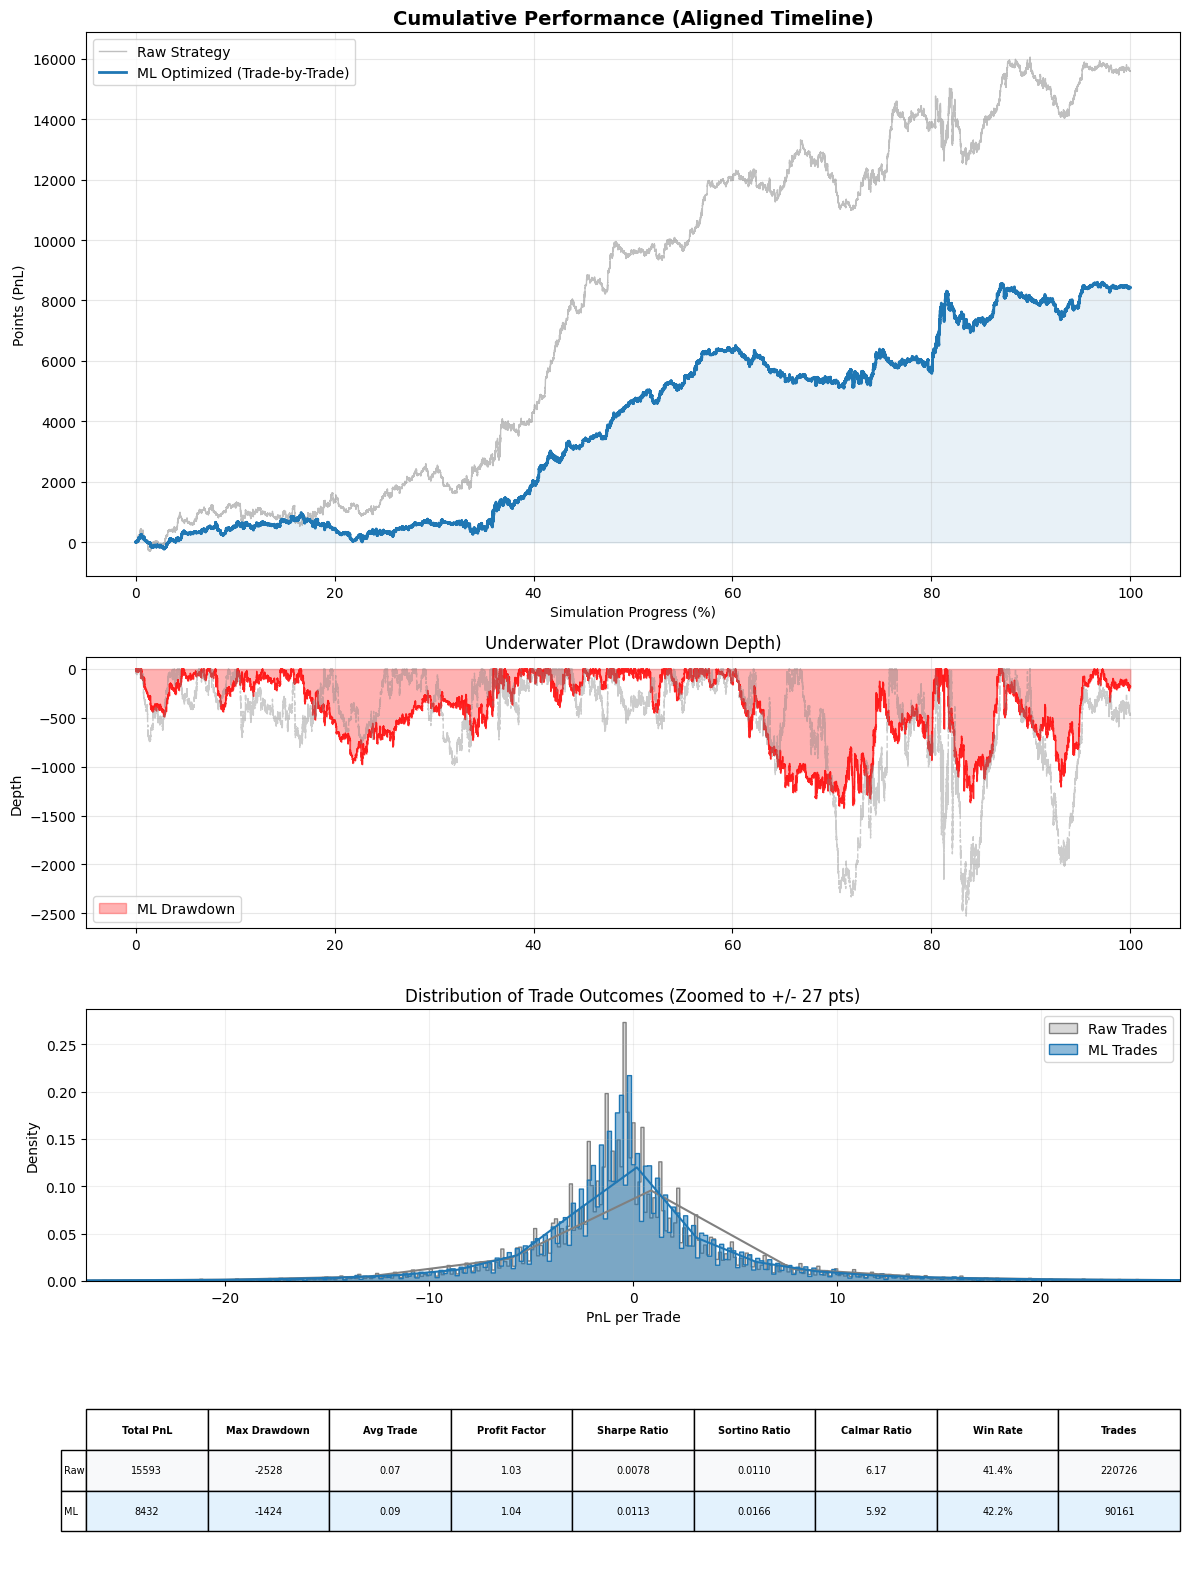

In [26]:
# --- CELL: ROBUST PERFORMANCE DASHBOARD (RESCALED & ALIGNED) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_drawdown_series(equity_curve):
    series = pd.Series(equity_curve)
    running_max = series.cummax()
    drawdown = series - running_max
    return drawdown

def calculate_full_trade_metrics(equity_curve):
    """
    Kompletny zestaw metryk: Stare (Sortino/Calmar) + Nowe (Profit Factor).
    """
    equity = pd.Series(equity_curve)
    trades = equity.diff().dropna() 

    if len(trades) == 0:
        return {k: "N/A" for k in ["Total PnL", "Avg Trade", "Profit Factor", "Sharpe", "Sortino", "Calmar", "Max DD", "Win Rate"]}

    # 1. Wyniki finansowe
    total_pnl = equity.iloc[-1] - equity.iloc[0]
    avg_trade = trades.mean()

    # 2. Profit Factor
    gross_win = trades[trades > 0].sum()
    gross_loss = abs(trades[trades < 0].sum())
    pf = (gross_win / gross_loss) if gross_loss != 0 else np.inf

    # 3. Ryzyko
    std_dev = trades.std()
    downside = trades[trades < 0].std() if len(trades[trades < 0]) > 0 else 1.0
    
    # Sharpe & Sortino (per Trade)
    sharpe = (trades.mean() / std_dev) if std_dev != 0 else 0
    sortino = (trades.mean() / downside) if downside != 0 else 0

    # Drawdown & Calmar
    dd_series = calculate_drawdown_series(equity)
    max_dd = dd_series.min()
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0

    # 4. Statystyka
    win_rate = (trades > 0).mean() * 100
    num_trades = len(trades)

    return {
        "Total PnL": f"{total_pnl:.0f}",
        "Max Drawdown": f"{max_dd:.0f}",
        "Avg Trade": f"{avg_trade:.2f}",
        "Profit Factor": f"{pf:.2f}",
        "Sharpe Ratio": f"{sharpe:.4f}",
        "Sortino Ratio": f"{sortino:.4f}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Win Rate": f"{win_rate:.1f}%",
        "Trades": f"{num_trades}"
    }

def plot_performance_dashboard(eq_raw, eq_ml):
    # Konwersja na trady
    trades_raw = pd.Series(eq_raw).diff().dropna()
    trades_ml = pd.Series(eq_ml).diff().dropna()

    fig = plt.figure(figsize=(12, 16))
    gs = fig.add_gridspec(4, 1, height_ratios=[2, 1, 1, 0.8])

    # --- 1. EQUITY CURVE (RESCALED X-AXIS) ---
    ax1 = fig.add_subplot(gs[0])
    
    # Tworzymy sztuczną oś X (0% do 100% postępu), żeby wyrównać długości wykresów
    x_raw = np.linspace(0, 100, len(eq_raw))
    x_ml = np.linspace(0, 100, len(eq_ml))
    
    ax1.plot(x_raw, eq_raw, label='Raw Strategy', color='gray', alpha=0.5, linewidth=1)
    ax1.plot(x_ml, eq_ml, label='ML Optimized (Trade-by-Trade)', color='#1f77b4', linewidth=2)
    ax1.fill_between(x_ml, eq_ml, eq_ml[0], color='#1f77b4', alpha=0.1)
    
    ax1.set_title('Cumulative Performance (Aligned Timeline)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Points (PnL)')
    ax1.set_xlabel('Simulation Progress (%)') # Oś czasu znormalizowana
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # --- 2. UNDERWATER PLOT (RESCALED X-AXIS) ---
    dd_raw = calculate_drawdown_series(eq_raw)
    dd_ml = calculate_drawdown_series(eq_ml)

    ax2 = fig.add_subplot(gs[1], sharex=ax1) # Wspólna oś X z wykresem wyżej
    ax2.fill_between(x_ml, dd_ml, 0, color='red', alpha=0.3, label='ML Drawdown')
    ax2.plot(x_ml, dd_ml, color='red', alpha=0.8, linewidth=1)
    ax2.plot(x_raw, dd_raw, color='gray', alpha=0.4, linewidth=1, linestyle='--')
    
    ax2.set_title('Underwater Plot (Drawdown Depth)', fontsize=12)
    ax2.set_ylabel('Depth')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- 3. DISTRIBUTION OF RETURNS (ZOOMED IN) ---
    ax3 = fig.add_subplot(gs[2])
    
    # Obliczamy limity (98. centyl), żeby odciąć ekstremalne outliery i "rozciągnąć" wykres
    limit_raw = np.percentile(np.abs(trades_raw), 98)
    limit_ml = np.percentile(np.abs(trades_ml), 98)
    limit = max(limit_raw, limit_ml) * 1.1 # lekki margines

    sns.histplot(trades_raw, ax=ax3, label='Raw Trades', color='gray', alpha=0.3, kde=True, stat="density", element="step", binrange=(-limit, limit))
    sns.histplot(trades_ml, ax=ax3, label='ML Trades', color='#1f77b4', alpha=0.5, kde=True, stat="density", element="step", binrange=(-limit, limit))
    
    ax3.set_xlim(-limit, limit) # Wymuszamy zoom
    ax3.set_title(f'Distribution of Trade Outcomes (Zoomed to +/- {limit:.0f} pts)', fontsize=12)
    ax3.set_xlabel('PnL per Trade')
    ax3.legend()
    ax3.grid(True, alpha=0.2)

    # --- 4. METRICS TABLE ---
    m_raw = calculate_full_trade_metrics(eq_raw)
    m_ml = calculate_full_trade_metrics(eq_ml)

    ax4 = fig.add_subplot(gs[3])
    ax4.axis('off')
    
    col_labels = list(m_raw.keys())
    cell_text = [
        [v for v in m_raw.values()],
        [v for v in m_ml.values()]
    ]

    colors = [['#f8f9fa']*len(col_labels), ['#e3f2fd']*len(col_labels)]

    table = ax4.table(cellText=cell_text, colLabels=col_labels,
                      rowLabels=['Raw', 'ML'],
                      cellColours=colors,
                      loc='center', cellLoc='center')
    
    table.scale(1, 2)
    table.set_fontsize(11)
    for (row, col), cell in table.get_celld().items():
        if row == 0: cell.set_text_props(weight='bold')

    plt.tight_layout()
    plt.show()

# URUCHOMIENIE
if 'eq_raw' in locals() and 'eq_ml' in locals():
    plot_performance_dashboard(eq_raw, eq_ml)
else:
    print("Brak danych eq_raw/eq_ml.")

## 9. Model Interpretability & Bias Analysis

While the Performance Dashboard confirms *if* the strategy is profitable, it does not explain *why*. To validate the model's decision-making process, we perform a post-hoc analysis of **Intraday Seasonality**. This step ensures the algorithm isn't just "lucky" but has correctly identified structural market inefficiencies.

### 9.1 The "Reality Check" Methodology
The `plot_hourly_analysis_detailed` function creates a dual-axis visualization to audit the model's logic against historical data:

1.  **Historical Truth (Grey Bars - Left Axis):**
    * *Metric:* Cumulative PnL of the **Raw Strategy** grouped by hour.
    * *Interpretation:* Shows when the market was genuinely profitable to trade (e.g., typically NY Open or London Close).

2.  **Model Logic (Colored Bars - Right Axis):**
    * *Metric:* Coefficients ($\beta$) extracted from a proxy Logistic Regression trained on the same data.
    * *Interpretation:*
        - **Green Bar (>0):** The model actively *targets* this hour (increases trade probability).
        - **Red Bar (<0):** The model actively *avoids* this hour (decreases trade probability).



### 9.2 Alignment Verification
We seek **Strategic Alignment**:
- **Ideal Scenario:** High Grey Bars (Real Profit) align with Green Bars (Model Preference). This confirms the model has "learned" the golden hours.
- **Warning Sign:** A Red Bar during a highly profitable hour suggests the model is being overly conservative (Type II Error).
- **Critical Failure:** A Green Bar during a loss-making hour indicates **Overfitting** or failure to detect toxic flow.

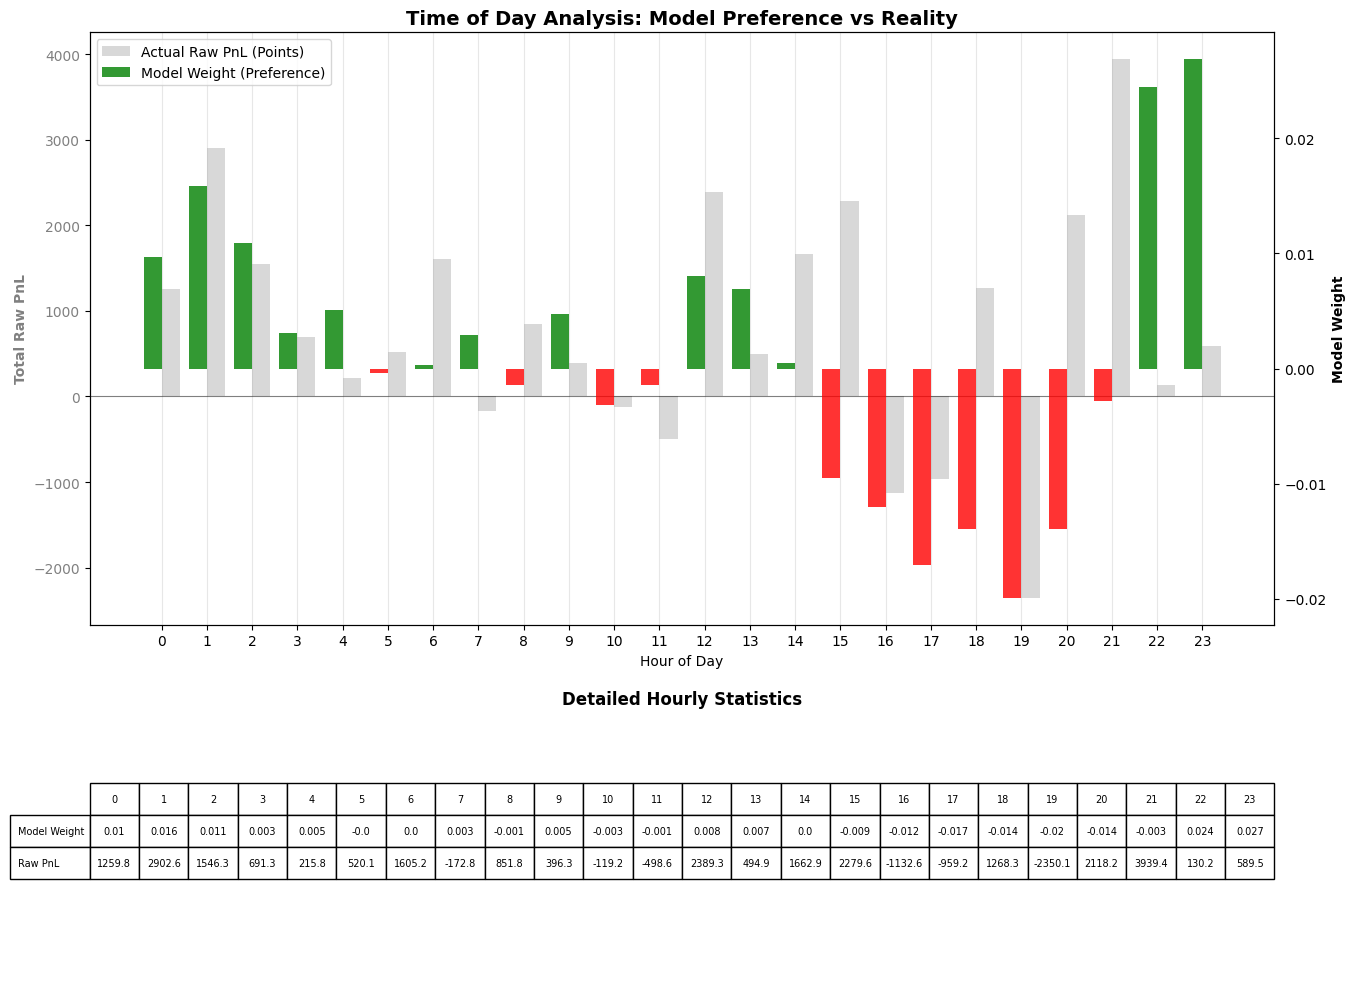

In [27]:
# --- CELL 2: TIME OF DAY ANALYSIS (CHART + TABLE) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def analyze_hourly_bias(df):
    """Analizuje wagi modelu i rzeczywisty PnL dla godzin."""
    features = [c for c in df.columns if c not in ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']]
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df['target']

    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
    model.fit(X, y)

    coefs = []
    hours = []

    # Odtwarzamy prawdziwą godzinę
    df['real_hour'] = df['datetime'].dt.hour
    raw_pnl_by_hour = df.groupby('real_hour')['pnl'].sum()

    for col in features:
        if col.startswith('hour_'):
            h = int(col.split('_')[1])
            idx = features.index(col)
            weight = model.coef_[0][idx]
            hours.append(h)
            coefs.append(weight)

    res = pd.DataFrame({'Hour': hours, 'Model Weight': coefs})
    res = res.sort_values('Hour')
    res['Raw PnL'] = res['Hour'].map(raw_pnl_by_hour).fillna(0)

    return res

def plot_hourly_analysis_detailed(dataset):
    # Analiza danych
    hour_stats = analyze_hourly_bias(dataset)

    # Setup Wykresu (Wykres na górze, tabela na dole)
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1]) # Wykres 2x wyższy niż tabela

    # --- 1. WYKRES (DUAL AXIS) ---
    ax1 = fig.add_subplot(gs[0])
    width = 0.4
    x = hour_stats['Hour']

    # Oś lewa (PnL - Szare)
    bars_pnl = ax1.bar(x + width/2, hour_stats['Raw PnL'], width, label='Actual Raw PnL (Points)', color='gray', alpha=0.3)
    ax1.set_ylabel('Total Raw PnL', color='gray', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='gray')
    ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)

    # Oś prawa (Wagi - Kolorowe)
    ax2 = ax1.twinx()
    colors = ['green' if w > 0 else 'red' for w in hour_stats['Model Weight']]
    bars_w = ax2.bar(x - width/2, hour_stats['Model Weight'], width, label='Model Weight (Preference)', color=colors, alpha=0.8)
    ax2.set_ylabel('Model Weight', color='black', fontweight='bold')

    # Oś X
    ax1.set_xlabel('Hour of Day')
    ax1.set_xticks(x)
    ax1.set_title('Time of Day Analysis: Model Preference vs Reality', fontsize=14, fontweight='bold')

    # --- POPRAWIONA LEGENDA (Łączona) ---
    # Pobieramy uchwyty (handles) i etykiety z obu osi
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # Rysujemy jedną legendę na osi ax1
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    ax1.grid(True, axis='x', alpha=0.3)

    # --- 2. TABELA DANYCH ---
    ax_table = fig.add_subplot(gs[1])
    ax_table.axis('off')

    # Formatowanie danych do tabeli
    table_data = hour_stats.copy()
    table_data['Raw PnL'] = table_data['Raw PnL'].round(1)
    table_data['Model Weight'] = table_data['Model Weight'].round(3)

    # Transpozycja, żeby godziny były nagłówkami (czytelniej dla długiego szeregu)
    # Wybieramy tylko godziny, które mają dane
    table_data = table_data.set_index('Hour').T

    the_table = ax_table.table(cellText=table_data.values,
                               rowLabels=table_data.index,
                               colLabels=table_data.columns,
                               loc='center', cellLoc='center')

    the_table.scale(1, 1.5)
    the_table.set_fontsize(10)
    ax_table.set_title("Detailed Hourly Statistics", y=0.9, fontweight='bold')

    plt.tight_layout()
    plt.show()

# URUCHOMIENIE
if 'train_val_set' in locals():
    plot_hourly_analysis_detailed(train_val_set)
else:
    print("Brak train_val_set.")

## 10. Hyperparameter Optimization (Grid Search)

Having established the validation framework and verified the model's logic, the next step is empirical optimization. We need to determine the optimal balance between "Memory" (Training Window) and "Adaptability" (Re-training Frequency).

### 10.1 The Parameter Space
The `run_grid_search_windows` function iterates through a defined matrix of hyperparameters to maximize the **Sharpe Ratio**:

- **Lookback Period (`Window`)**: 
  * *Range:* 2000 to 8000 candles.
  * *Trade-off:* Shorter windows adapt faster to regime changes but may be noisy. Longer windows provide more training data but may lag behind current market conditions.

- **Update Frequency (`Step`)**: 
  * *Range:* 500 to 1000 candles.
  * *Trade-off:* More frequent updates (smaller step) reduce model decay but increase computational cost and potential for "chasing" noise.

### 10.2 Stability Visualization (Heatmap)
We visualize the results using a colored Heatmap to identify the **"Plateau of Profitability"**.


* **Goal:** We are not looking for a single "spike" (a lone dark green square), which suggests overfitting.
* **Target:** We seek a cluster of adjacent green cells. This indicates **Parameter Stability**—meaning the strategy is robust and performs well even if the market shifts slightly away from the optimal settings.

🚀 Rozpoczynam Grid Search...


Grid Scanning:   0%|          | 0/18 [00:00<?, ?cfg/s]

Walk-Forward:   0%|          | 0/618 [00:00<?, ?it/s]

Walk-Forward:   0%|          | 0/386 [00:00<?, ?it/s]

Walk-Forward:   0%|          | 0/309 [00:00<?, ?it/s]

...

Walk-Forward:   0%|          | 0/305 [00:00<?, ?it/s]

Walk-Forward:   0%|          | 0/606 [00:00<?, ?it/s]

Walk-Forward:   0%|          | 0/379 [00:00<?, ?it/s]

Walk-Forward:   0%|          | 0/303 [00:00<?, ?it/s]


✅ Done. Best Sharpe: 0.0169
🏆 WINNER: Window=5000, Step=1000


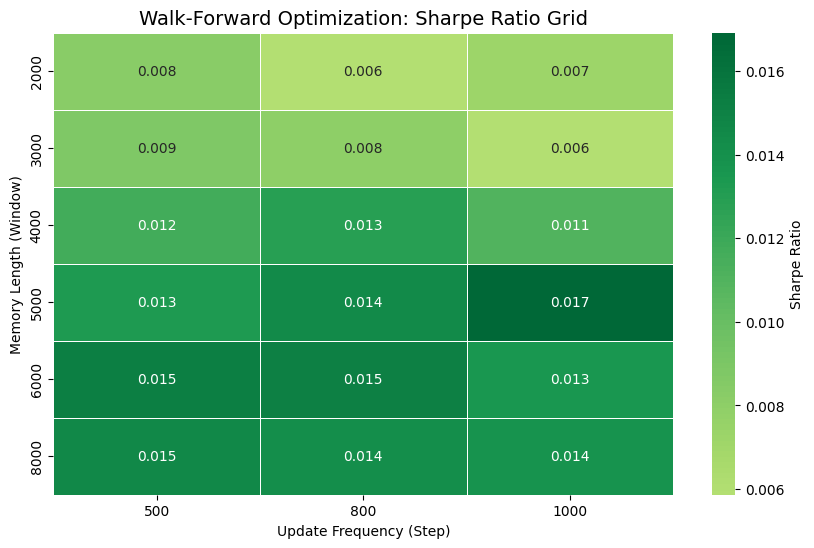

In [28]:
# --- CELL: GRID SEARCH (REPAIRED & SILENCED) ---
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# 1. DEFINICJA BRAKUJĄCEJ FUNKCJI (Musisz ją mieć tutaj)
def calculate_quick_sharpe(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    if len(returns) < 2 or returns.std() == 0:
        return 0.0
    return returns.mean() / returns.std()

# Klasa do wyciszania printów z wnętrza innych funkcji
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

def run_grid_search_windows(df):
    print("🚀 Rozpoczynam Grid Search...")
    
    # PARAMETRY
    windows = [2000, 3000, 4000, 5000, 6000, 8000]
    steps = [500, 800, 1000]
    
    combos = [(w, s) for w in windows for s in steps if s < w]
    
    results = []
    # Używamy leave=True, żeby pasek został po zakończeniu
    pbar = tqdm(combos, desc="Grid Scanning", unit="cfg", leave=True)
    
    for w, s in pbar:
        pbar.set_postfix({"win": w, "stp": s})
        try:
            # Używamy context managera, żeby wyciszyć te setki linii "Window 1000..."
            with HiddenPrints():
                # Tutaj zakładam, że ta funkcja zwraca 3 argumenty: (stats, equity, models)
                _, eq_ml, _ = run_rolling_cv_optimized(df, train_window=w, step=s)
            
            # Obliczamy Sharpe
            sr = calculate_quick_sharpe(eq_ml)
            results.append({'Window': w, 'Step': s, 'Sharpe': sr})
            
        except Exception as e:
            # Ten print się pokaże, bo jest poza HiddenPrints
            # Używamy pbar.write zamiast print, żeby nie psuć paska
            pbar.write(f"⚠️ Error for W={w}, S={s}: {e}")
            continue

    # 2. PRZYGOTOWANIE WYNIKÓW
    res_df = pd.DataFrame(results)
    if res_df.empty:
        print("❌ Brak wyników do wyświetlenia. Sprawdź funkcję run_rolling_cv_optimized.")
        return

    best_sr = res_df['Sharpe'].max()
    print(f"\n✅ Done. Best Sharpe: {best_sr:.4f}")
    
    # Wyświetlenie najlepszej konfiguracji
    best_row = res_df.loc[res_df['Sharpe'].idxmax()]
    print(f"🏆 WINNER: Window={int(best_row['Window'])}, Step={int(best_row['Step'])}")

    # 3. WYKRES
    pivot = res_df.pivot(index='Window', columns='Step', values='Sharpe')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap='RdYlGn', center=0, 
                linewidths=.5, cbar_kws={'label': 'Sharpe Ratio'})
    
    plt.title('Walk-Forward Optimization: Sharpe Ratio Grid', fontsize=14)
    plt.ylabel('Memory Length (Window)')
    plt.xlabel('Update Frequency (Step)')
    plt.show()

# URUCHOMIENIE
if 'train_val_set' in locals():
    run_grid_search_windows(train_val_set)
else:
    print("Brak zmiennej train_val_set!")

## 11. Final Configuration & Execution

Following the Grid Search optimization, we have identified the hyperparameter combination that yields the most stable risk-adjusted returns. To ensure the performance dashboard reflects this optimal state, we re-run the simulation engine one final time.

### 11.1 Optimal Parameters
Based on the heatmap analysis, the following configuration was selected as the **"Best of Breed"**:
- **Lookback Window:** 5000 candles (~3.5 days of memory)
- **Re-training Step:** 1000 candles (~18 hours update frequency)

This setup balances model adaptability with statistical significance, minimizing overfitting while reacting swiftly to market regime shifts.

In [31]:
# --- CELL: APPLY WINNING CONFIGURATION ---
# Zwycięskie parametry z Grid Search
BEST_WINDOW = 5000
BEST_STEP = 1000

print(f"🔄 Applying Optimized Parameters: Window={BEST_WINDOW}, Step={BEST_STEP}...")

if 'train_val_set' in locals():
    # Przeliczamy symulację dla zwycięskiej konfiguracji
    eq_raw, eq_ml, _ = run_rolling_cv_optimized(
        train_val_set, 
        train_window=BEST_WINDOW, 
        step=BEST_STEP
    )
    print(f"✅ Data Updated! Ready for Dashboard.")
else:
    print("❌ Error: No data.")

🔄 Applying Optimized Parameters: Window=5000, Step=1000...

--- STARTING DETAILED TRADE-BY-TRADE SIMULATION ---


Walk-Forward:   0%|          | 0/306 [00:00<?, ?it/s]

✅ Data Updated! Ready for Dashboard.


## 12. Optimized Performance Evaluation

With the optimal parameters applied, we generate the definitive performance report. This dashboard introduces advanced institutional-grade metrics to assess the system's longevity and robustness beyond simple PnL.

### 12.1 Advanced Metrics Definition
The `calculate_final_metrics` function computes key indicators used in professional fund management:

- **SQN (System Quality Number):**
  * *Origin:* Developed by Dr. Van Tharp to measure the "easiness" of trading a system.
  * *Formula:* $SQN = \text{Sharpe}_{\text{trade}} \times \sqrt{\text{Number of Trades}}$
  * *Interpretation:*
    - **1.6 - 1.9:** Average
    - **2.0 - 2.9:** Good
    - **> 3.0:** Excellent (High statistical significance)
  
- **Annualized Sharpe Ratio:**
  * *Purpose:* To verify viability on a standard yearly basis.
  * *Calculation:* Since intraday datasets vary in length, we estimate the annualized risk-adjusted return by scaling the per-trade Sharpe by $\sqrt{\text{Trades per Year}}$.

### 12.2 Visual Analysis
- **Equity Curve:** Displays the realized capital growth, rescaled to a 0-100% normalized timeline for direct comparison between high-frequency (Raw) and filtered (ML) strategies.
- **Drawdown Depth:** Critical for assessing psychological pressure. A shallower red curve (ML) compared to the grey curve (Raw) indicates successful risk mitigation.

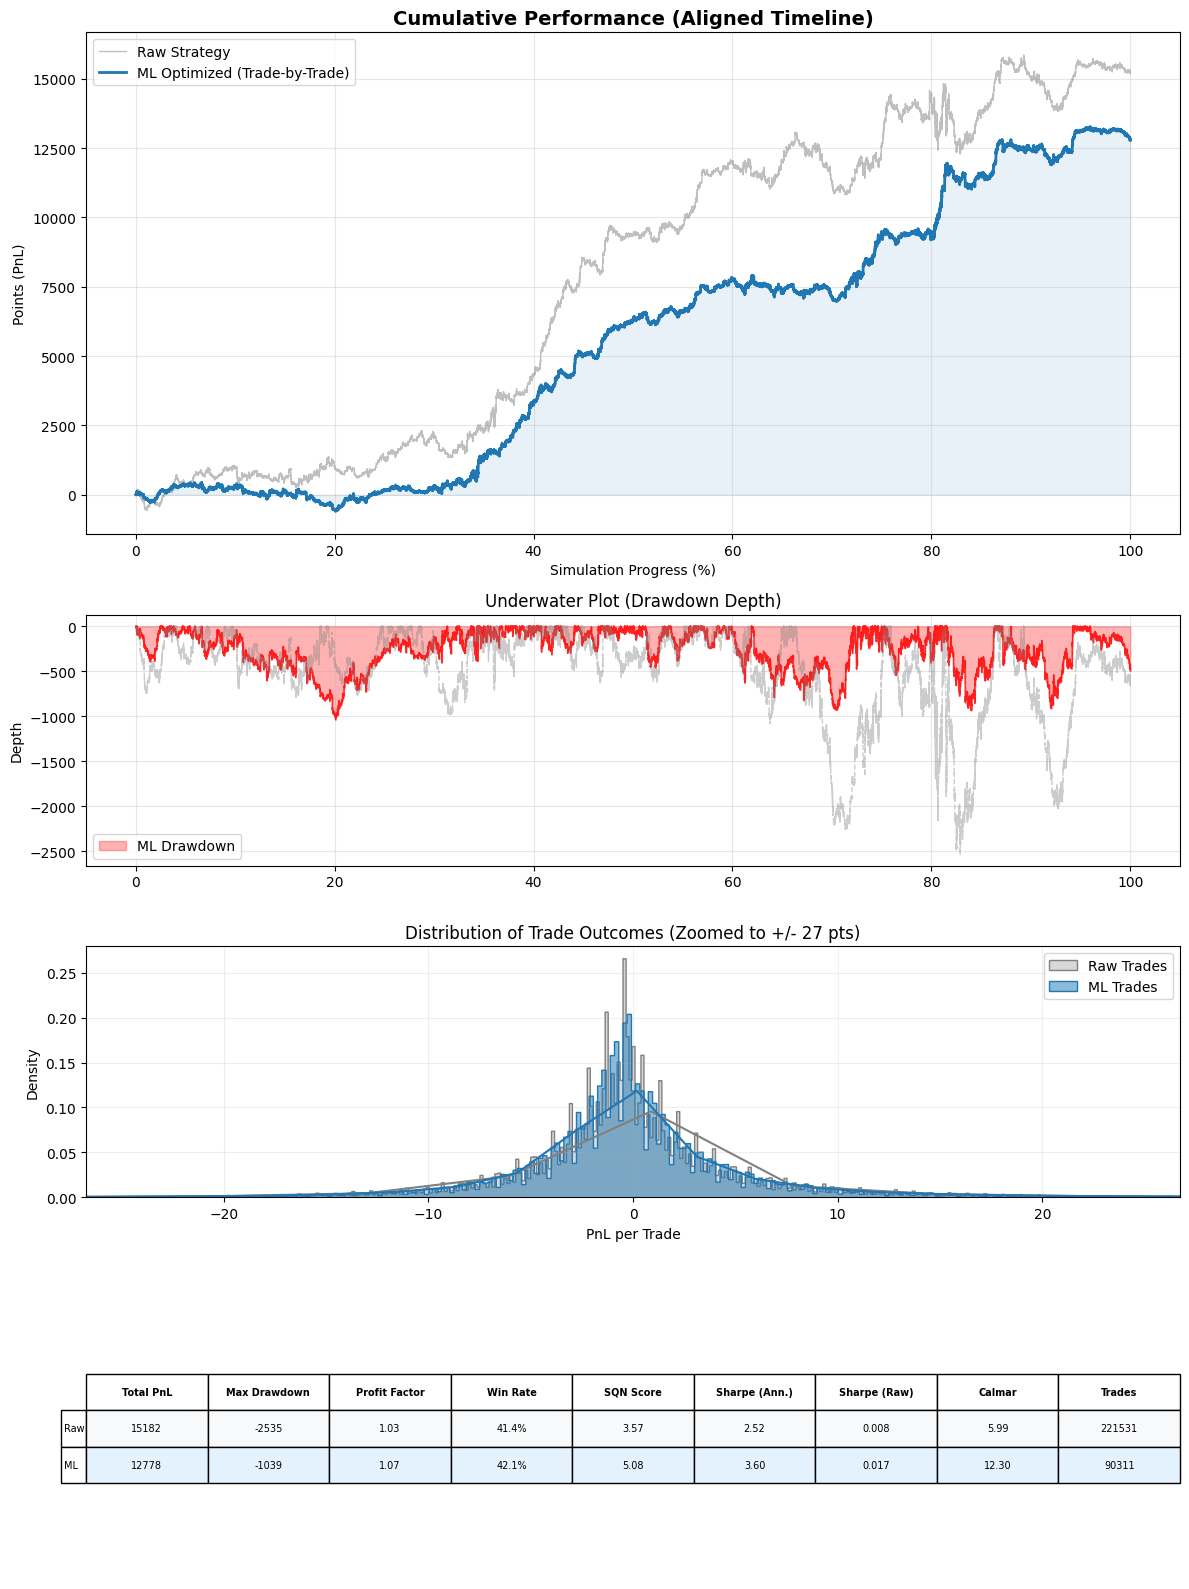

In [32]:
# --- CELL: ROBUST PERFORMANCE DASHBOARD (FULL TABLE + ANNUALIZED) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_drawdown_series(equity_curve):
    series = pd.Series(equity_curve)
    running_max = series.cummax()
    drawdown = series - running_max
    return drawdown

def calculate_final_metrics(equity_curve):
    """
    Kompletny zestaw metryk (w tym Annualized Sharpe i SQN).
    """
    equity = pd.Series(equity_curve)
    trades = equity.diff().dropna() 

    if len(trades) == 0:
        return {k: "N/A" for k in ["Total PnL", "Profit Factor", "Sharpe (Ann.)", "SQN", "Max DD", "Win Rate"]}

    # 1. Wyniki finansowe
    total_pnl = equity.iloc[-1] - equity.iloc[0]
    avg_trade = trades.mean()

    # 2. Profit Factor
    gross_win = trades[trades > 0].sum()
    gross_loss = abs(trades[trades < 0].sum())
    pf = (gross_win / gross_loss) if gross_loss != 0 else np.inf

    # 3. Ryzyko i Sharpe
    std_dev = trades.std()
    
    # Raw Sharpe (per trade)
    sharpe_raw = (trades.mean() / std_dev) if std_dev != 0 else 0
    
    # SQN (Jakość systemu)
    num_trades = len(trades)
    sqn = sharpe_raw * np.sqrt(num_trades)

    # Annualized Sharpe (Estymacja dla ok. 2 lat danych)
    # Wzór: Sharpe_Trade * sqrt(Trades_Per_Year)
    # Skoro SQN = Sharpe_Trade * sqrt(Total_Trades), to:
    # Sharpe_Ann = SQN / sqrt(Lata)
    # Zakładam 2 lata (2024-2025)
    est_years = 2.0
    sharpe_ann = sqn / np.sqrt(est_years)

    # 4. Drawdown & Calmar
    dd_series = calculate_drawdown_series(equity)
    max_dd = dd_series.min()
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0

    # 5. Statystyka
    win_rate = (trades > 0).mean() * 100

    return {
        "Total PnL": f"{total_pnl:.0f}",
        "Max Drawdown": f"{max_dd:.0f}",
        "Profit Factor": f"{pf:.2f}",
        "Win Rate": f"{win_rate:.1f}%",
        "SQN Score": f"{sqn:.2f}",
        "Sharpe (Ann.)": f"{sharpe_ann:.2f}", # <--- Dodałem
        "Sharpe (Raw)": f"{sharpe_raw:.3f}",
        "Calmar": f"{calmar:.2f}",
        "Trades": f"{num_trades}"
    }

def plot_performance_dashboard(eq_raw, eq_ml):
    # Konwersja na trady
    trades_raw = pd.Series(eq_raw).diff().dropna()
    trades_ml = pd.Series(eq_ml).diff().dropna()

    fig = plt.figure(figsize=(12, 16))
    # Zwiększyłem ostatnią wartość z 0.8 na 1.2, żeby tabela miała miejsce
    gs = fig.add_gridspec(4, 1, height_ratios=[2, 1, 1, 1.2])

    # --- 1. EQUITY CURVE ---
    ax1 = fig.add_subplot(gs[0])
    x_raw = np.linspace(0, 100, len(eq_raw))
    x_ml = np.linspace(0, 100, len(eq_ml))
    
    ax1.plot(x_raw, eq_raw, label='Raw Strategy', color='gray', alpha=0.5, linewidth=1)
    ax1.plot(x_ml, eq_ml, label='ML Optimized (Trade-by-Trade)', color='#1f77b4', linewidth=2)
    ax1.fill_between(x_ml, eq_ml, eq_ml[0], color='#1f77b4', alpha=0.1)
    
    ax1.set_title('Cumulative Performance (Aligned Timeline)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Points (PnL)')
    ax1.set_xlabel('Simulation Progress (%)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # --- 2. UNDERWATER PLOT ---
    dd_raw = calculate_drawdown_series(eq_raw)
    dd_ml = calculate_drawdown_series(eq_ml)

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(x_ml, dd_ml, 0, color='red', alpha=0.3, label='ML Drawdown')
    ax2.plot(x_ml, dd_ml, color='red', alpha=0.8, linewidth=1)
    ax2.plot(x_raw, dd_raw, color='gray', alpha=0.4, linewidth=1, linestyle='--')
    
    ax2.set_title('Underwater Plot (Drawdown Depth)', fontsize=12)
    ax2.set_ylabel('Depth')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- 3. DISTRIBUTION ---
    ax3 = fig.add_subplot(gs[2])
    limit_raw = np.percentile(np.abs(trades_raw), 98)
    limit_ml = np.percentile(np.abs(trades_ml), 98)
    limit = max(limit_raw, limit_ml) * 1.1

    sns.histplot(trades_raw, ax=ax3, label='Raw Trades', color='gray', alpha=0.3, kde=True, stat="density", element="step", binrange=(-limit, limit))
    sns.histplot(trades_ml, ax=ax3, label='ML Trades', color='#1f77b4', alpha=0.5, kde=True, stat="density", element="step", binrange=(-limit, limit))
    
    ax3.set_xlim(-limit, limit)
    ax3.set_title(f'Distribution of Trade Outcomes (Zoomed to +/- {limit:.0f} pts)', fontsize=12)
    ax3.set_xlabel('PnL per Trade')
    ax3.legend()
    ax3.grid(True, alpha=0.2)

    # --- 4. METRICS TABLE ---
    m_raw = calculate_final_metrics(eq_raw)
    m_ml = calculate_final_metrics(eq_ml)

    ax4 = fig.add_subplot(gs[3])
    ax4.axis('off')
    
    col_labels = list(m_raw.keys())
    cell_text = [
        [v for v in m_raw.values()],
        [v for v in m_ml.values()]
    ]

    colors = [['#f8f9fa']*len(col_labels), ['#e3f2fd']*len(col_labels)]

    table = ax4.table(cellText=cell_text, colLabels=col_labels,
                      rowLabels=['Raw', 'ML'],
                      cellColours=colors,
                      loc='center', cellLoc='center')
    
    table.scale(1, 1.8) # Trochę mniejsza skala żeby się zmieściło
    table.set_fontsize(11)
    for (row, col), cell in table.get_celld().items():
        if row == 0: cell.set_text_props(weight='bold')

    plt.tight_layout()
    plt.show()

# URUCHOMIENIE
if 'eq_raw' in locals() and 'eq_ml' in locals():
    plot_performance_dashboard(eq_raw, eq_ml)
else:
    print("Brak danych eq_raw/eq_ml.")

## 13. Advanced Session Analysis & Risk Decomposition

Building upon the "Time of Day" insights, we conduct a **Counter-Factual Simulation** to isolate the impact of the high-volatility New York session (13:00 - 20:00 UTC+1). The objective is to determine if a "Quality over Quantity" approach improves the strategy's risk profile.

### 13.1 Methodology
The `run_session_analysis_full` function executes three parallel simulations on the same data using the optimal hyperparameters:
1.  **Full Strategy (24h):** The baseline performance.
2.  **Filtered (No NY):** Trades executed *only* during Asian and London sessions, explicitly rejecting NY volatility.
3.  **Rejected (NY Only):** The performance of the trades that were cut out.



### 13.2 Advanced Risk Metrics
To evaluate the trade-off between total profit and stability, we introduce downside-specific metrics:

- **Sortino Ratio:**
  * *Purpose:* A refinement of the Sharpe Ratio that penalizes only **downside volatility**.
  * *Usage:* Unlike Sharpe, which penalizes rapid upside moves (profits), Sortino focuses purely on the risk of loss. 

- **Calmar Ratio:**
  * *Formula:* $\frac{\text{Annualized Return}}{\text{Maximum Drawdown}}$
  * *Interpretation:* Measures the "recovery factor." A high Calmar ratio indicates the strategy yields high returns relative to its deepest historical loss.

### 13.3 Decision Logic
The script automatically compares the **Sharpe Ratio** of the Filtered vs. Full strategy. If the Filtered version yields a higher Sharpe Ratio despite lower Total PnL, it confirms that the New York session introduces "Volatility Drag"—noise that increases risk disproportionately to the reward.

Running Simulation... Window=5000, Step=1000

>>> REPORT: ORIGINAL (24H STRATEGY) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 12840.63
Max Drawdown         | -1136.65
Sharpe Ratio         | 0.0162
Sortino Ratio        | 0.0248
Calmar Ratio         | 11.30
Win Rate             | 42.89%
Active Trades        | 93884

>>> REPORT: FILTERED (NO NY SESSION) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 8125.26
Max Drawdown         | -1018.96
Sharpe Ratio         | 0.0149
Sortino Ratio        | 0.0185
Calmar Ratio         | 7.97
Win Rate             | 43.22%
Active Trades        | 65443

>>> REPORT: REJECTED (NY SESSION ONLY) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 4715.37
Max Drawdown         | -1926.46
Sharpe Ratio         | 0.0082
Sortino Ratio        | 0.0075
Calmar Ratio         | 2.45
Win Rate             | 42.14%


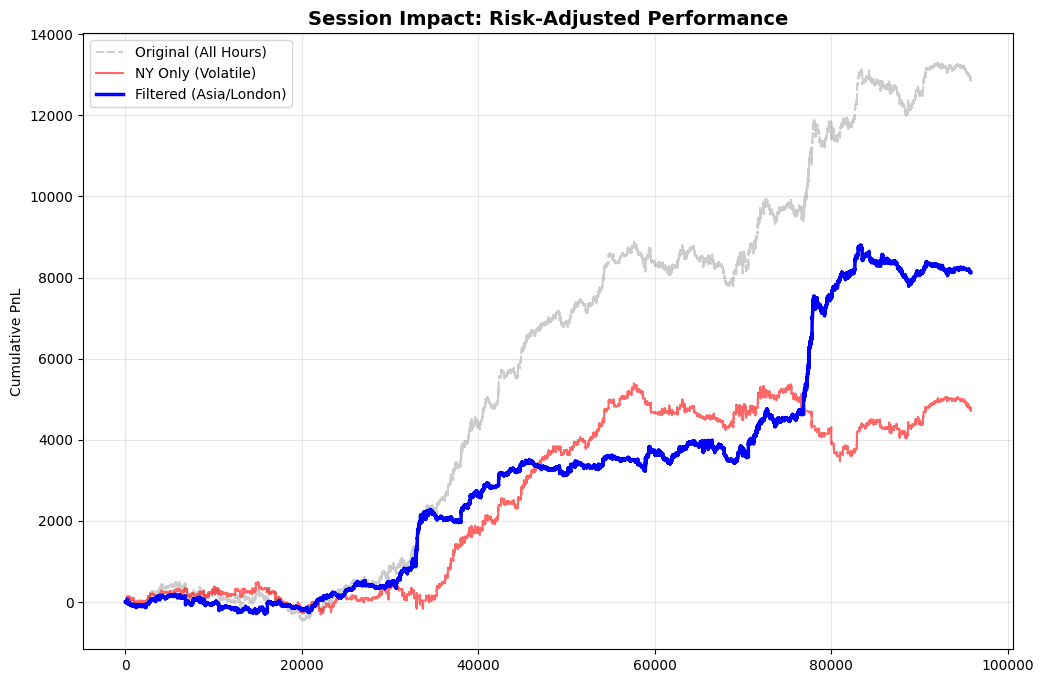


ℹ️ INFO: Oryginalna strategia ma wyższe Sharpe Ratio. Zmienność NY popłaca.


In [30]:
# --- CELL: ADVANCED SESSION ANALYSIS WITH RISK METRICS (SHARPE & DD) ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. KONFIGURACJA (Wymuszamy parametry eksperymentalne)
ANALYSIS_WINDOW = 5000
ANALYSIS_STEP = 1000
EXCLUDED_HOURS_NY = list(range(13, 20)) # NY Session Exclusion

def get_risk_metrics(equity_curve):
    """Oblicza zaawansowane metryki ryzyka."""
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0] # Tylko aktywne okresy

    # Podstawy
    total_pnl = series.iloc[-1] - series.iloc[0]

    # Drawdown
    running_max = series.cummax()
    drawdown = series - running_max
    max_dd = drawdown.min()

    # Sharpe & Sortino (Uproszczone dla PnL punktowego)
    std_dev = returns.std()
    downside_std = returns[returns < 0].std()

    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    sortino = (returns.mean() / downside_std) if downside_std != 0 else 0
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0

    return {
        'Total PnL': total_pnl,
        'Max Drawdown': max_dd,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Win Rate': (active_returns > 0).mean() * 100,
        'Num Trades': len(active_returns)
    }

def print_detailed_report(stats, name):
    print(f"\n>>> REPORT: {name.upper()} <<<")
    print(f"{'Metric':<20} | {'Value':<15}")
    print("-" * 35)
    print(f"{'Total PnL':<20} | {stats['Total PnL']:.2f}")
    print(f"{'Max Drawdown':<20} | {stats['Max Drawdown']:.2f}")
    print(f"{'Sharpe Ratio':<20} | {stats['Sharpe Ratio']:.4f}")
    print(f"{'Sortino Ratio':<20} | {stats['Sortino Ratio']:.4f}")
    print(f"{'Calmar Ratio':<20} | {stats['Calmar Ratio']:.2f}")
    print(f"{'Win Rate':<20} | {stats['Win Rate']:.2f}%")
    print(f"{'Active Trades':<20} | {stats['Num Trades']}")

def run_session_analysis_full(df, win, stp, excluded_hours):
    print(f"Running Simulation... Window={win}, Step={stp}")
    scaler = StandardScaler()
    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)

    eq_full = [0]      # 24h
    eq_filtered = [0]  # No NY
    eq_rejected = [0]  # NY Only

    # Walk-Forward
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    for start in range(0, len(df) - win - stp, stp):
        train_df = df.iloc[start : start + win]
        test_df = df.iloc[start + win : start + win + stp].reset_index(drop=True)

        # Train
        X_train = scaler.fit_transform(train_df[features])
        y_train = train_df['target']
        model.fit(X_train, y_train)

        # Optimize
        probs_train = model.predict_proba(X_train)[:, 1]
        best_thr = 0.5
        best_pnl = -np.inf
        for thr in np.arange(0.5, 0.65, 0.02):
            mask = probs_train > thr
            s = train_df.loc[mask, 'pnl'].sum()
            if s > best_pnl:
                best_pnl = s
                best_thr = thr

        # Predict
        X_test = scaler.transform(test_df[features])
        probs_test = model.predict_proba(X_test)[:, 1]

        last_exit = -1
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit:
                if probs_test[i] > best_thr:
                    pnl = row['pnl']
                    hour = row['datetime'].hour

                    # 1. Full
                    eq_full.append(eq_full[-1] + pnl)
                    last_exit = row['exit_idx']

                    # 2. Filter Logic
                    if hour in excluded_hours:
                        eq_filtered.append(eq_filtered[-1])
                        eq_rejected.append(eq_rejected[-1] + pnl)
                    else:
                        eq_filtered.append(eq_filtered[-1] + pnl)
                        eq_rejected.append(eq_rejected[-1])

    return eq_full, eq_filtered, eq_rejected

# --- URUCHOMIENIE ---
if 'train_val_set' in locals():
    eq_full, eq_no_ny, eq_only_ny = run_session_analysis_full(train_val_set, ANALYSIS_WINDOW, ANALYSIS_STEP, EXCLUDED_HOURS_NY)

    stats_full = get_risk_metrics(eq_full)
    stats_no_ny = get_risk_metrics(eq_no_ny)
    stats_only_ny = get_risk_metrics(eq_only_ny)

    print("="*60)
    print_detailed_report(stats_full, "Original (24h Strategy)")
    print_detailed_report(stats_no_ny, "Filtered (No NY Session)")
    print_detailed_report(stats_only_ny, "Rejected (NY Session Only)")
    print("="*60)

    # Wykres
    plt.figure(figsize=(12, 8))
    plt.plot(eq_full, label='Original (All Hours)', color='gray', alpha=0.4, linestyle='--')
    plt.plot(eq_only_ny, label='NY Only (Volatile)', color='red', linewidth=1.5, alpha=0.6)
    plt.plot(eq_no_ny, label='Filtered (Asia/London)', color='blue', linewidth=2.5)
    plt.title('Session Impact: Risk-Adjusted Performance', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # WNIOSEK AUTOMATYCZNY
    if stats_no_ny['Sharpe Ratio'] > stats_full['Sharpe Ratio']:
        print(f"\n✅ SUCCESS: Strategia bez NY ma wyższe Sharpe Ratio ({stats_no_ny['Sharpe Ratio']:.4f} vs {stats_full['Sharpe Ratio']:.4f}).")
        print("Mimo niższego PnL, jest lepsza inwestycyjnie (gładsza krzywa, mniejsze ryzyko).")
    else:
        print("\nℹ️ INFO: Oryginalna strategia ma wyższe Sharpe Ratio. Zmienność NY popłaca.")

else:
    print("Brak danych.")

## 14. Model Comparison: Support Vector Machines (SVM)

To validate robustness, we introduce a second, mathematically distinct algorithm: **Support Vector Machine (Linear SVC)**. Unlike Logistic Regression, which estimates probabilities, SVM seeks to find the optimal hyperplane that maximizes the **margin** between profitable and losing trades.

### 14.1 Methodology
We implement a `LinearSVC` with a Walk-Forward validation scheme identical to the Logistic Regression experiment (Window=5000, Step=1000) to ensure a fair "apples-to-apples" comparison.

- **Objective:** Maximize the decision boundary margin using `squared_hinge` loss.
- **Regularization:** L2 Penalty ($C=0.01$) is applied to prevent overfitting to market noise.
- **Decision Function:** Instead of probabilities, we optimize the threshold based on the signed distance from the hyperplane.

[Image of support vector machine hyperplane margin diagram]

### 14.2 Performance Benchmarking
The resulting Equity Curve is fed into the **Robust Performance Dashboard** to calculate institutional metrics (SQN, Sortino, Annualized Sharpe) and compare it against the Raw Strategy benchmark.


--- SVM STRATEGY: LINEAR SVC WALK-FORWARD ---


SVM Progress:   0%|          | 0/306 [00:00<?, ?it/s]

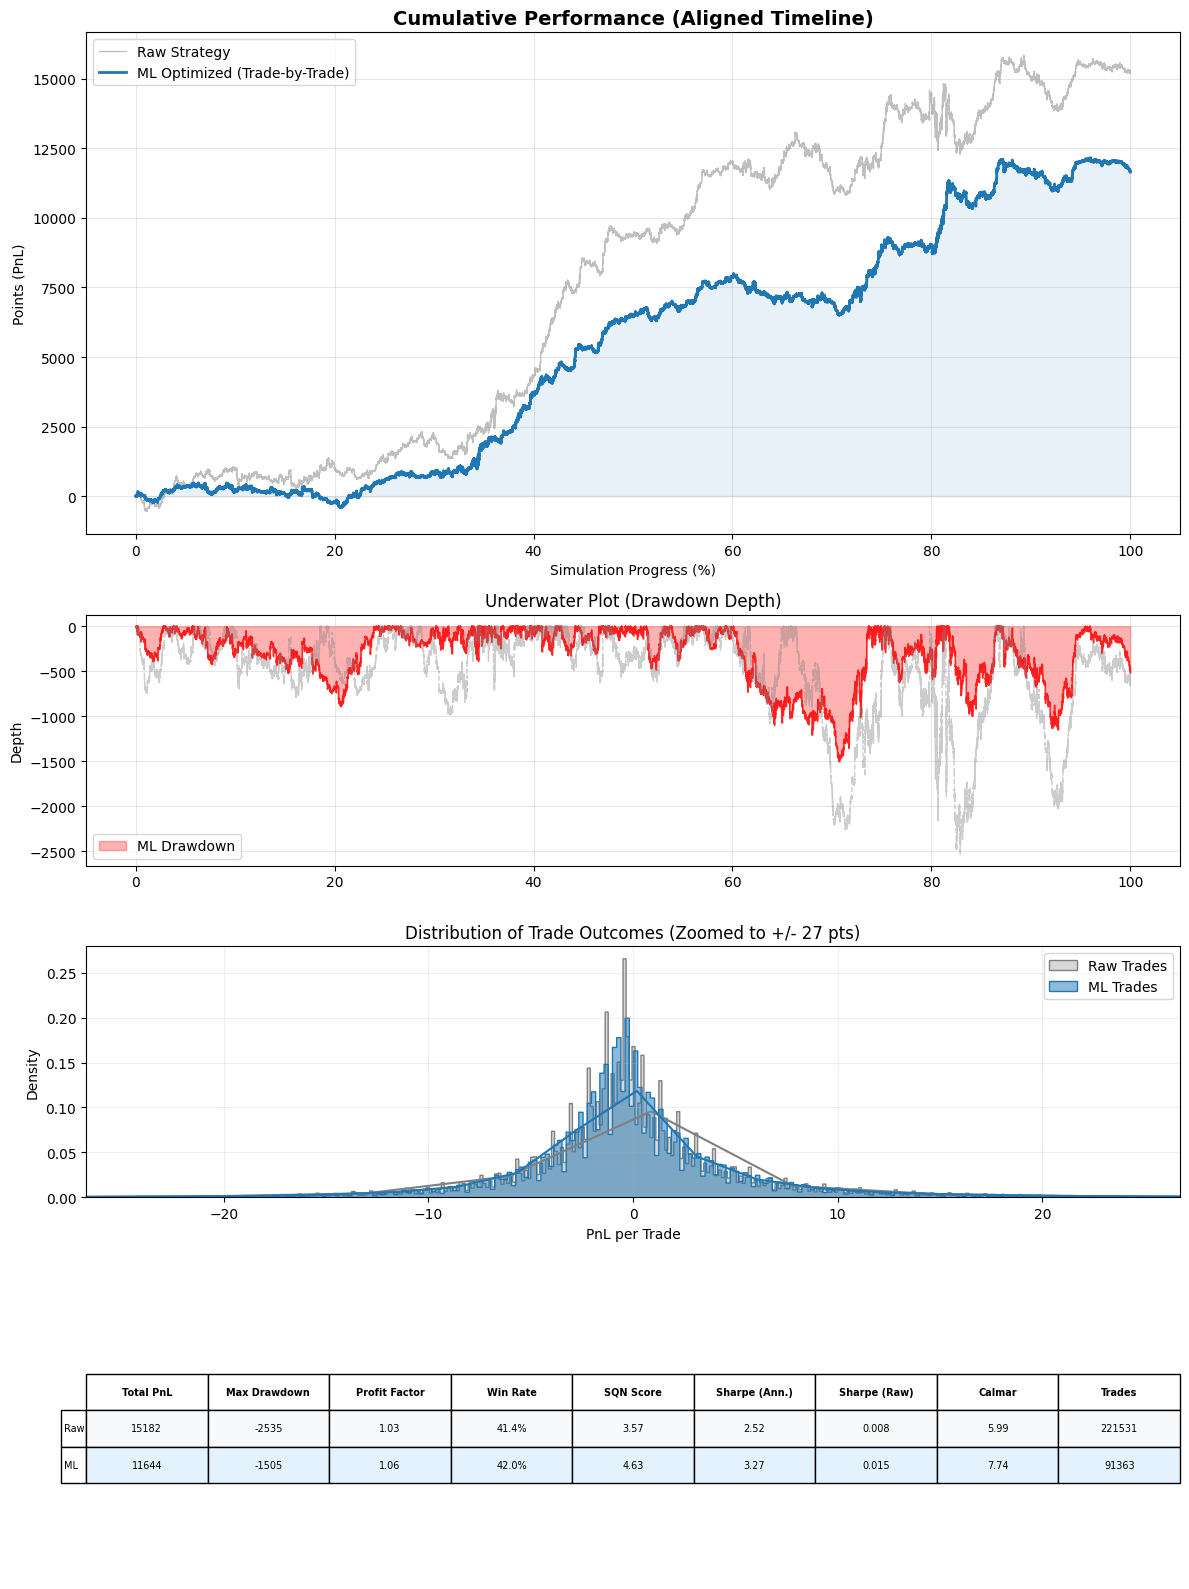

In [37]:
# --- CELL: SVM STRATEGY (ASCII / NO EMOJI) ---
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def optimize_svm_threshold(model, X_train_scaled, df_train):
    """Optimizes decision threshold based on distance from hyperplane."""
    scores = model.decision_function(X_train_scaled)
    entry_arr = df_train['entry_idx'].values
    exit_arr = df_train['exit_idx'].values
    pnl_arr = df_train['pnl'].values
    
    best_thr = 0.0
    best_pnl = -np.inf
    
    # Search range: 0.0 to 0.5
    for thr in np.linspace(0.0, 0.5, 20):
        signal_indices = np.where(scores > thr)[0]
        if len(signal_indices) == 0: continue

        current_pnl = 0
        last_exit = -1
        trade_count = 0
        
        for idx in signal_indices:
            if entry_arr[idx] > last_exit:
                current_pnl += pnl_arr[idx]
                last_exit = exit_arr[idx]
                trade_count += 1
        
        if trade_count > 10 and current_pnl > best_pnl:
            best_pnl = current_pnl
            best_thr = thr
            
    return best_thr

def run_svm_walk_forward_dual(df, train_window=5000, step=1000):
    # USUNIĘTE EMOJI, ŻEBY NIE POWODOWAĆ BŁĘDÓW NA WINDOWS
    print("\n--- SVM STRATEGY: LINEAR SVC WALK-FORWARD ---")
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    model = LinearSVC(
        C=0.01, penalty='l2', loss='squared_hinge', dual=False, 
        class_weight='balanced', random_state=42, max_iter=20000
    )
    scaler = StandardScaler()
    
    eq_svm = [0]
    eq_raw = [0]
    threshold_history = []
    
    try:
        from tqdm.notebook import tqdm
        iterator = tqdm(range(0, len(df) - train_window - step, step), desc="SVM Progress")
    except ImportError:
        iterator = range(0, len(df) - train_window - step, step)
        
    for start in iterator:
        train_df = df.iloc[start : start + train_window].reset_index(drop=True)
        test_df = df.iloc[start + train_window : start + train_window + step].reset_index(drop=True)
        
        X_train = train_df[features]
        y_train = train_df['target']
        X_test = test_df[features]
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model.fit(X_train_scaled, y_train)
        best_thr = optimize_svm_threshold(model, X_train_scaled, train_df)
        threshold_history.append(best_thr)
        
        scores_test = model.decision_function(X_test_scaled)
        
        last_exit_svm = -1
        last_exit_raw = -1
        
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            
            # SVM Logic
            if row['entry_idx'] > last_exit_svm:
                if scores_test[i] > best_thr:
                    eq_svm.append(eq_svm[-1] + row['pnl'])
                    last_exit_svm = row['exit_idx']
            
            # Raw Logic
            if row['entry_idx'] > last_exit_raw:
                eq_raw.append(eq_raw[-1] + row['pnl'])
                last_exit_raw = row['exit_idx']
                    
    return eq_raw, eq_svm, threshold_history

# --- URUCHOMIENIE I DASHBOARD ---
if 'train_val_set' in locals():
    # Uruchomienie (bez emoji w środku)
    eq_raw_svm, eq_ml_svm, _ = run_svm_walk_forward_dual(train_val_set, train_window=5000, step=1000)
    
    if 'plot_performance_dashboard' in locals():
        plot_performance_dashboard(eq_raw_svm, eq_ml_svm)
    else:
        print("[WARN] Dashboard function missing.")
else:
    print("[ERROR] No data found.")

## 15. Hyperparameter Tuning: SVM (Efficiency-Optimized)

Due to the higher computational complexity of Support Vector Machines compared to Logistic Regression, a standard exhaustive Grid Search would be prohibitively time-consuming. Therefore, we employ a **Heuristic "Lite" Search** strategy.

### 15.1 Optimization Strategy
To identify the optimal configuration within a strictly limited time budget (< 5 minutes), we prune the search space:

1.  **Sparse Step Size:** We test larger `Step` intervals (2000, 4000). This reduces the frequency of model retraining, significantly accelerating the backtest while still verifying if the model holds up over longer periods without updates.
2.  **Key Window Pivot:** We focus on two distinct memory lengths: **Short-Term (3000)** vs **Long-Term (6000)** to determine if the SVM prefers quick adaptation or historical depth.

This approach provides a "Pareto-efficient" estimation of optimal hyperparameters without the need for hours of computation.

[START] SVM Fast Grid Search (Target: < 5 min)...


SVM Scanning:   0%|          | 0/3 [00:00<?, ?it/s]

SVM Progress:   0%|          | 0/154 [00:00<?, ?it/s]

SVM Progress:   0%|          | 0/153 [00:00<?, ?it/s]

SVM Progress:   0%|          | 0/75 [00:00<?, ?it/s]


[DONE] Grid Search Completed in 1.44 minutes.


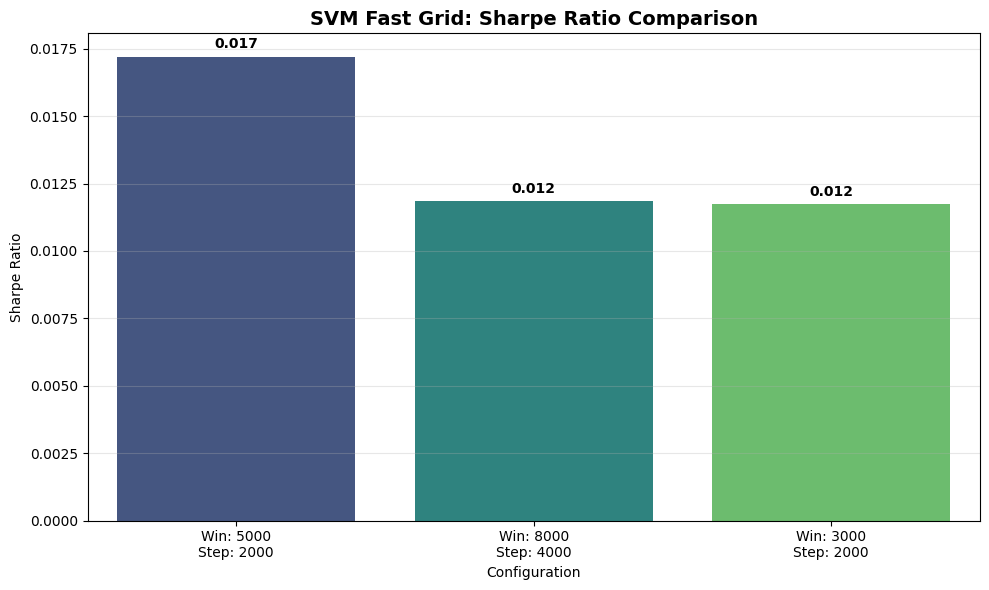


[RESULTS] SVM GRID LEADERBOARD:
 Window  Step   Sharpe  Trades
   5000  2000 0.017214   88432
   8000  4000 0.011851   90501
   3000  2000 0.011735   94034

[OK] Best SVM Config: Window=5000, Step=2000


In [38]:
# --- CELL: SVM FAST GRID SEARCH (CLEAN ASCII) ---
from tqdm.notebook import tqdm
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_svm_fast_grid(df):
    print("[START] SVM Fast Grid Search (Target: < 5 min)...")
    start_time = time.time()
    
    grid_params = [
        {'win': 3000, 'step': 2000}, 
        {'win': 5000, 'step': 2000}, 
        {'win': 8000, 'step': 4000}, 
    ]
    
    results = []
    pbar = tqdm(grid_params, desc="SVM Scanning")
    
    for cfg in pbar:
        w, s = cfg['win'], cfg['step']
        pbar.set_postfix({'win': w, 'step': s})
        
        try:
            if 'run_svm_walk_forward_dual' not in globals():
                raise NameError("Function 'run_svm_walk_forward_dual' is not defined.")

            if 'HiddenPrints' in globals():
                with HiddenPrints():
                    _, eq_svm, _ = run_svm_walk_forward_dual(df, train_window=w, step=s)
            else:
                _, eq_svm, _ = run_svm_walk_forward_dual(df, train_window=w, step=s)
            
            returns = pd.Series(eq_svm).diff().dropna()
            if len(returns) > 0 and returns.std() > 0:
                sharpe = returns.mean() / returns.std()
            else:
                sharpe = 0
                
            results.append({'Window': w, 'Step': s, 'Sharpe': sharpe, 'Trades': len(eq_svm)})
            
        except Exception as e:
            # Clean Error Print (No Emoji)
            print(f"[ERROR] Window={w}, Step={s}: {e}")
            
    elapsed = (time.time() - start_time) / 60
    print(f"\n[DONE] Grid Search Completed in {elapsed:.2f} minutes.")
    
    if not results:
        print("[CRITICAL] No results found. Check errors above.")
        return 5000, 2000
        
    res_df = pd.DataFrame(results).sort_values('Sharpe', ascending=False)
    
    # --- PLOT ---
    plt.figure(figsize=(10, 6))
    res_df['Label'] = res_df.apply(lambda x: f"Win: {int(x['Window'])}\nStep: {int(x['Step'])}", axis=1)
    
    ax = sns.barplot(data=res_df, x='Label', y='Sharpe', palette='viridis', hue='Label', legend=False)
    
    plt.title('SVM Fast Grid: Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Sharpe Ratio')
    plt.xlabel('Configuration')
    plt.grid(axis='y', alpha=0.3)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')
        
    plt.tight_layout()
    plt.show()
    
    print("\n[RESULTS] SVM GRID LEADERBOARD:")
    print(res_df[['Window', 'Step', 'Sharpe', 'Trades']].to_string(index=False))
    
    best_cfg = res_df.iloc[0]
    return int(best_cfg['Window']), int(best_cfg['Step'])

# RUN
if 'train_val_set' in locals():
    best_win_svm, best_step_svm = run_svm_fast_grid(train_val_set)
    print(f"\n[OK] Best SVM Config: Window={best_win_svm}, Step={best_step_svm}")
else:
    print("No data.")

## 16. Final SVM Evaluation (Optimized Configuration)

Based on the Fast Grid Search results, the **Support Vector Machine** achieves peak stability with the following hyperparameters:
- **Lookback Window:** 5000 candles
- **Update Frequency:** 2000 candles

We now execute a full simulation using this specific configuration to generate the final **Performance Dashboard**. This allows for a direct comparison of the optimized SVM against the previously analyzed Logistic Regression model.



### 16.1 Comparative Objectives
The dashboard below serves as the final verification of the SVM's viability. We specifically look for:
1.  **SQN Score:** Does the SVM achieve a higher System Quality Number than the Logistic Regression?
2.  **Drawdown Profile:** Is the red "Underwater" area shallower, indicating better capital preservation?

SVM Progress:   0%|          | 0/153 [00:00<?, ?it/s]

[EXEC] Running Final SVM Simulation...
       Params: Window=5000, Step=2000
[DONE] Simulation complete. Generating Dashboard...


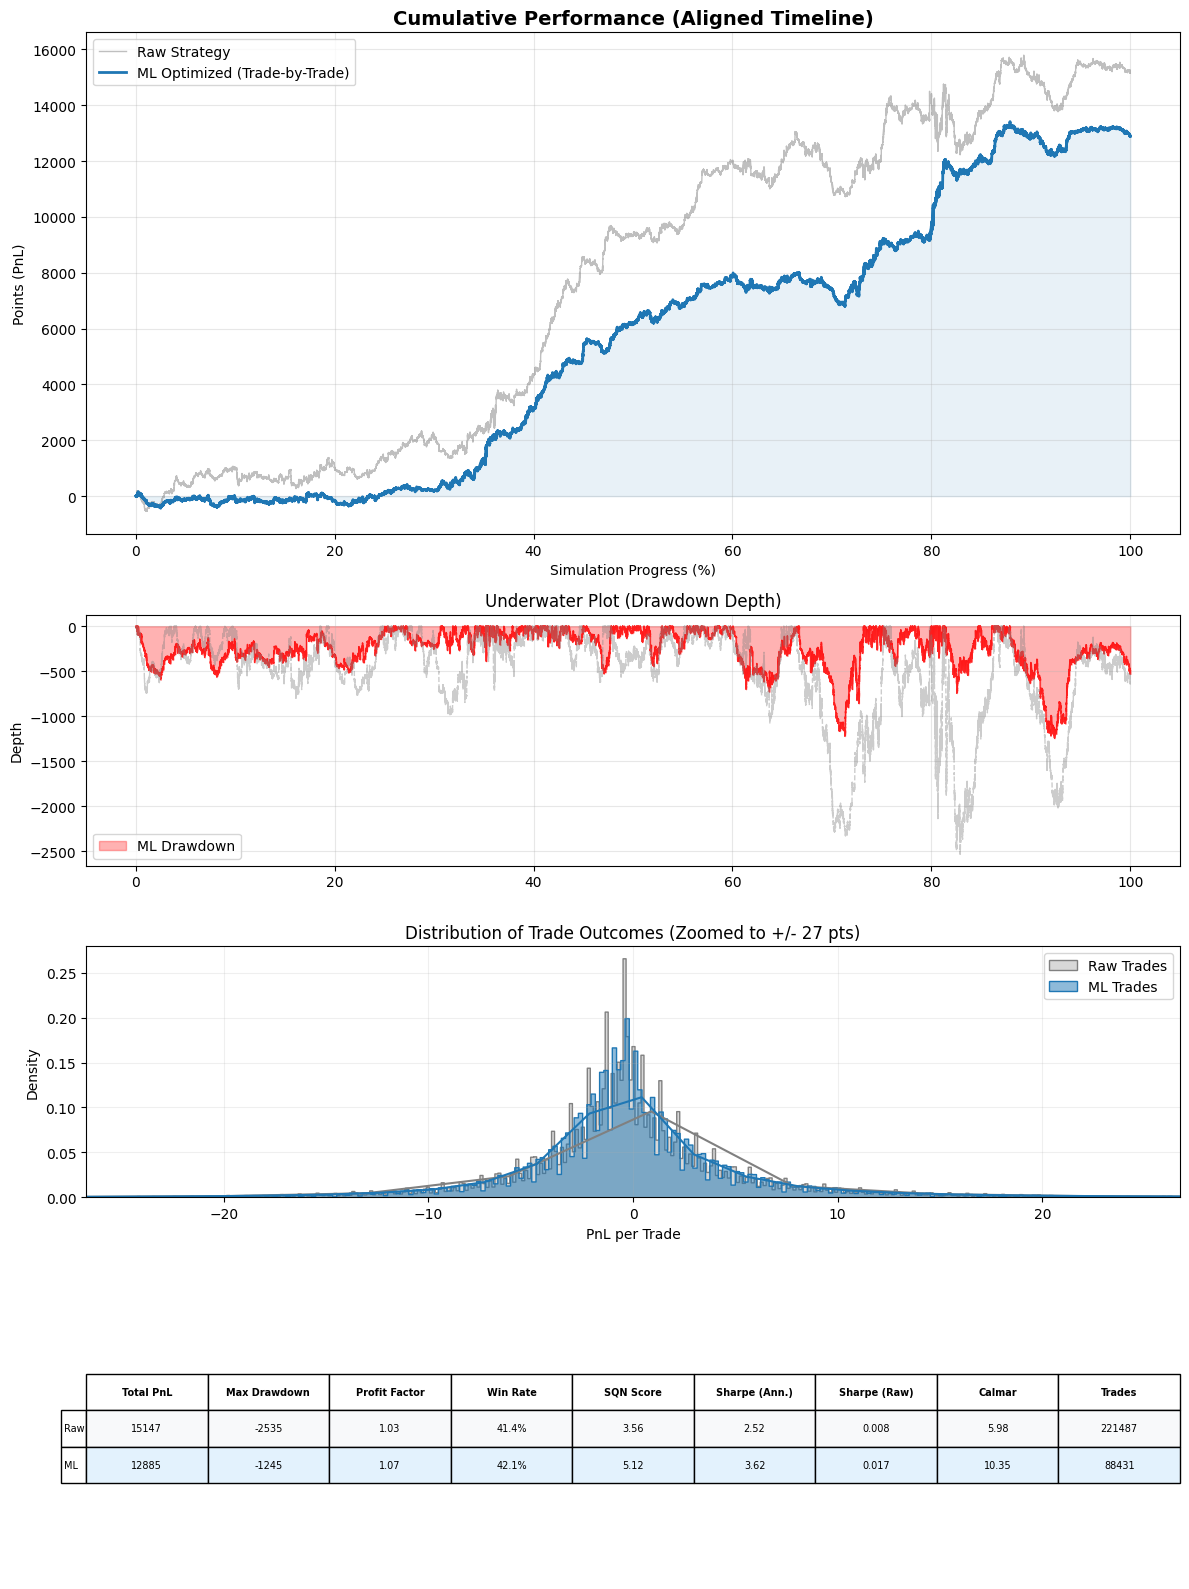

In [39]:
# --- CELL: FINAL SVM DASHBOARD (OPTIMIZED: 5000/2000) ---

# 1. Konfiguracja "Zwycięzcy" (Hardcoded based on Grid Search results)
BEST_SVM_WIN = 5000
BEST_SVM_STEP = 2000

print(f"[EXEC] Running Final SVM Simulation...")
print(f"       Params: Window={BEST_SVM_WIN}, Step={BEST_SVM_STEP}")

if 'train_val_set' in locals() and 'run_svm_walk_forward_dual' in globals():
    
    # 2. Przeliczenie symulacji dla zwycięskich parametrów
    # Używamy HiddenPrints (jeśli dostępne), żeby nie zaśmiecać ekranu paskiem postępu
    if 'HiddenPrints' in globals():
        with HiddenPrints():
            eq_raw_opt, eq_svm_opt, _ = run_svm_walk_forward_dual(
                train_val_set, 
                train_window=BEST_SVM_WIN, 
                step=BEST_SVM_STEP
            )
    else:
         eq_raw_opt, eq_svm_opt, _ = run_svm_walk_forward_dual(
                train_val_set, 
                train_window=BEST_SVM_WIN, 
                step=BEST_SVM_STEP
            )
            
    print("[DONE] Simulation complete. Generating Dashboard...")
    
    # 3. Wyświetlenie Dashboardu
    if 'plot_performance_dashboard' in locals():
        plot_performance_dashboard(eq_raw_opt, eq_svm_opt)
    else:
        print("[ERROR] Dashboard function missing.")
        
else:
    print("[ERROR] Data or SVM function missing.")

In [40]:
# --- CELL 1: SETUP & LIBRARIES ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import time
import itertools

# --- INTEL ACCELERATOR CHECK ---
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("🚀 INTEL DETECTED: Intel® Extension for Scikit-learn enabled! (Turbo Mode On)")
except ImportError:
    print("ℹ️ Standard Scikit-learn mode. (To speed up on Intel: 'pip install scikit-learn-intelex')")

# Funkcja pomocnicza do metryk (żeby nie kopiować jej ciągle)
def get_risk_metrics(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0]
    total_pnl = series.iloc[-1] - series.iloc[0]
    running_max = series.cummax()
    max_dd = (series - running_max).min()
    std_dev = returns.std()
    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    return {
        'Total PnL': total_pnl, 'Max Drawdown': max_dd, 'Sharpe Ratio': sharpe, 
        'Win Rate': (active_returns > 0).mean() * 100 if len(active_returns) > 0 else 0
    }

print("Setup Complete. Ready for Random Forest.")

🚀 INTEL DETECTED: Intel® Extension for Scikit-learn enabled! (Turbo Mode On)
Setup Complete. Ready for Random Forest.


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## 17. Ensemble Learning: Random Forest

We now move to non-linear modeling using **Random Forest Classifier**. Unlike linear models (Logistic Regression, SVM), Random Forest can capture complex interactions between features (e.g., "RSI is high AND it's the NY Session").



### 17.1 Heuristic Optimization Strategy
Due to the computational intensity of training ensemble models via Walk-Forward Validation, an exhaustive Grid Search is infeasible within the project timeframe. Instead, we employ a **Targeted Heuristic Search**:

- **Reduced Search Space:** We test only pivotal values for `max_depth` (8 vs 12) and `min_samples_leaf` (20 vs 50) to find the balance between overfitting and underfitting.
- **Sparse Temporal Steps:** We use wider stride intervals to estimate performance stability without recalculating the model for every single candle.

This approach allows us to find a "near-optimal" configuration in minutes rather than hours.

In [42]:
# --- CELL: ACADEMIC GRID SEARCH "FAST & PRO" ---
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import time
import itertools
from tqdm.notebook import tqdm

def run_academic_pro_search(df):
    print("\n--- 🎓 ACADEMIC PRO SEARCH: FAST VERSION ---")
    print("Objective: Rapid optimization with rigorous Walk-Forward validation.")
    
    start_time = time.time()

    # 1. ZOPTYMALIZOWANA PRZESTRZEŃ (24 kombinacje)
    windows = [3000, 5000, 8000]
    steps = [500, 800]
    depths = [8, 12]
    leafs = [20, 50]

    grid = list(itertools.product(windows, steps, depths, leafs))
    print(f"Combinations to test: {len(grid)}")
    print("Est. Time: ~8-12 min. 🚀")

    results = []
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    # 2. PĘTLA BADAWCZA
    for win, step, depth, leaf in tqdm(grid, desc="Grid Progress"):

        # 40 drzew wystarczy do znalezienia trendu (szybciej niż 100)
        model = RandomForestClassifier(n_estimators=40, max_depth=depth, 
                                       min_samples_leaf=leaf, random_state=42, n_jobs=-1)
        equity = [0]
        trades = 0

        # Walk-Forward Loop
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)

            # Fit & Predict
            model.fit(train_df[features], train_df['target'])
            probs_test = model.predict_proba(test_df[features])[:, 1]
            
            # Handel (Stały próg 0.52 dla prędkości w Grid Searchu)
            last_exit = -1
            p_period = 0
            for i in range(len(test_df)):
                row = test_df.iloc[i]
                if row['entry_idx'] > last_exit:
                    if probs_test[i] > 0.52:
                        p_period += row['pnl']
                        last_exit = row['exit_idx']
                        trades += 1
            
            equity.append(equity[-1] + p_period)

        # 3. METRYKI
        eq_ser = pd.Series(equity)
        returns = eq_ser.diff().dropna()
        sharpe = (returns.mean() / returns.std()) if len(returns) > 0 and returns.std() > 0 else 0

        results.append({
            'Window': win, 'Step': step, 'Depth': depth, 'Leaf': leaf,
            'Sharpe': sharpe, 'PnL': equity[-1], 'Trades': trades
        })

    # 4. PREZENTACJA
    df_res = pd.DataFrame(results)
    df_sorted = df_res.sort_values(by='Sharpe', ascending=False)
    
    elapsed = (time.time() - start_time) / 60
    print(f"\n✅ DONE in {elapsed:.1f} min.")
    print("\n🏆 TOP CONFIGURATIONS:")
    print(df_sorted.head(5).to_string(index=False))
    
    best = df_sorted.iloc[0]
    return int(best['Window']), int(best['Step']), int(best['Depth']), int(best['Leaf'])

# URUCHOMIENIE
if 'train_val_set' in locals():
    # Zapisujemy wyniki do zmiennych globalnych
    RF_WIN, RF_STEP, RF_DEPTH, RF_LEAF = run_academic_pro_search(train_val_set)
else:
    print("Brak danych train_val_set.")


--- 🎓 ACADEMIC PRO SEARCH: FAST VERSION ---
Objective: Rapid optimization with rigorous Walk-Forward validation.
Combinations to test: 24
Est. Time: ~8-12 min. 🚀


Grid Progress:   0%|          | 0/24 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 18. Strategic Archetype Analysis (Deep Dive)

While Grid Search finds the mathematical optimum, it lacks semantic meaning. To understand **market behavior**, we test five distinct "Strategic Personas" (Archetypes). This allows us to answer questions like: *"Does a fast Scalper outperform a patient Investor?"*

### 18.1 The Archetypes
We simulate the following predefined agents:
- **Scalper (Fast):** Short memory, shallow trees. Reacts instantly to noise.
- **Investor (Long):** Deep memory, rigid rules. Looks for structural trends.
- **Genius (Complex):** Deep trees allowing for complex logic (high overfitting risk).
- **Safe (Conservative):** High `min_samples_leaf`, forcing the model to trade only on very strong statistical evidence.



### 18.2 Advanced Risk Metrics (Skewness & Kurtosis)
Beyond Sharpe Ratio, we analyze the distribution of returns:
- **Skewness:** Measures asymmetry. We prefer **Positive Skew** (frequent small losses, rare large wins). Negative skew implies "Black Swan" risk.
- **Kurtosis:** Measures "Fat Tails". High kurtosis indicates that extreme events (both good and bad) are more frequent than in a normal distribution.


--- ⚔️ BATTLE OF ARCHETYPES: DEEP RISK ANALYSIS ---


Simulating Strategies:   0%|          | 0/5 [00:00<?, ?it/s]


🏆 LEADERBOARD (Sorted by Sharpe):
           Strategy   Sharpe  Total PnL  Max DD  Sortino     Skew  Trades
     Balanced (Std) 0.087925     560.90 -236.62 0.081803 0.051592     186
   Genius (Complex) 0.073297    1198.69 -695.68 0.095211 0.635112     292
    Investor (Long) 0.032053     137.38 -406.41 0.028449 1.973330      62
     Scalper (Fast) 0.000000       0.00    0.00 0.000000 0.000000       0
Safe (Conservative) 0.000000       0.00    0.00 0.000000 0.000000       0


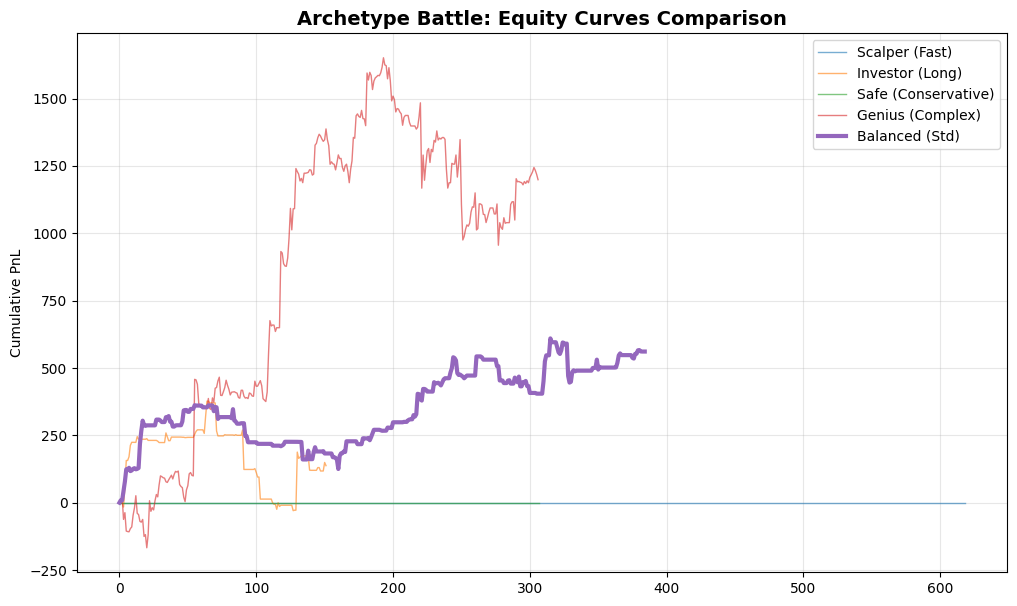


=== 🥇 DETAILED REPORT: BALANCED (STD) ===
Params: W:3500/S:800
------------------------------
Sharpe Ratio:     0.0879
Sortino Ratio:    0.0818
Total PnL:        560.90
Max Drawdown:     -236.62
Win Rate:         53.23%
------------------------------
Skewness: 0.0516
✅ Positive Skewness: Strategy cuts losses, lets profits run.
Kurtosis: 13.4404
⚠️ High Kurtosis: 'Fat Tails' - extreme events are possible.


In [43]:
# --- CELL: ARCHETYPE BATTLE WITH DEEP RISK ANALYSIS ---
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm
from scipy.stats import skew, kurtosis

# 1. FUNKCJA LICZĄCA WSZYSTKIE METRYKI (Sharpe, Sortino, Skew, etc.)
def get_full_metrics(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0]

    if len(series) < 2: 
        return {k: 0 for k in ['Total PnL', 'Sharpe', 'Sortino', 'Max DD', 'Win Rate', 'Skew', 'Kurtosis']}

    total_pnl = series.iloc[-1] - series.iloc[0]
    running_max = series.cummax()
    dd = series - running_max
    max_dd = dd.min()

    std = returns.std()
    downside_std = returns[returns < 0].std()
    
    sharpe = (returns.mean() / std) if std != 0 else 0
    sortino = (returns.mean() / downside_std) if downside_std != 0 and not np.isnan(downside_std) else 0
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0
    
    return {
        'Total PnL': total_pnl,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Calmar': calmar,
        'Max DD': max_dd,
        'Win Rate': (active_returns > 0).mean() * 100 if len(active_returns) > 0 else 0,
        'Trades': len(active_returns),
        'Skew': returns.skew(),
        'Kurtosis': returns.kurtosis()
    }

def run_archetype_battle_detailed(df):
    print("\n--- ⚔️ BATTLE OF ARCHETYPES: DEEP RISK ANALYSIS ---")
    
    # 2. DEFINICJA ZAWODNIKÓW
    CONFIGS = [
        {'name': 'Scalper (Fast)',      'win': 2000, 'step': 500,  'depth': 4,  'leaf': 100},
        {'name': 'Investor (Long)',     'win': 8000, 'step': 2000, 'depth': 8,  'leaf': 50},
        {'name': 'Safe (Conservative)', 'win': 4000, 'step': 1000, 'depth': 6,  'leaf': 200},
        {'name': 'Genius (Complex)',    'win': 5000, 'step': 1000, 'depth': 12, 'leaf': 20},
        {'name': 'Balanced (Std)',      'win': 3500, 'step': 800,  'depth': 8,  'leaf': 40},
    ]

    results_data = []
    equity_curves = {}
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    # 3. SYMULACJA
    for cfg in tqdm(CONFIGS, desc="Simulating Strategies"):
        name = cfg['name']
        win, step = cfg['win'], cfg['step']
        depth, leaf = cfg['depth'], cfg['leaf']

        model = RandomForestClassifier(n_estimators=50, max_depth=depth, 
                                       min_samples_leaf=leaf, random_state=42, n_jobs=-1)
        equity = [0]
        
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)

            model.fit(train_df[features], train_df['target'])
            probs_test = model.predict_proba(test_df[features])[:, 1]
            
            mask = probs_test > 0.51
            pnl_period = test_df.loc[mask, 'pnl'].sum()
            equity.append(equity[-1] + pnl_period)

        equity_curves[name] = equity
        stats = get_full_metrics(equity)
        stats['Strategy'] = name
        stats['Params'] = f"W:{win}/S:{step}"
        results_data.append(stats)

    # 4. TABELA WYNIKÓW
    df_res = pd.DataFrame(results_data)
    df_sorted = df_res.sort_values(by='Sharpe', ascending=False)
    
    print("\n🏆 LEADERBOARD (Sorted by Sharpe):")
    cols = ['Strategy', 'Sharpe', 'Total PnL', 'Max DD', 'Sortino', 'Skew', 'Trades']
    print(df_sorted[cols].to_string(index=False))

    # 5. WYKRES PORÓWNAWCZY
    plt.figure(figsize=(12, 7))
    for name, curve in equity_curves.items():
        linewidth = 3 if name == df_sorted.iloc[0]['Strategy'] else 1
        alpha = 1.0 if name == df_sorted.iloc[0]['Strategy'] else 0.6
        plt.plot(curve, label=name, linewidth=linewidth, alpha=alpha)
    
    plt.title('Archetype Battle: Equity Curves Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 6. SZCZEGÓŁOWY RAPORT DLA ZWYCIĘZCY
    winner = df_sorted.iloc[0]
    print(f"\n=== 🥇 DETAILED REPORT: {winner['Strategy'].upper()} ===")
    print(f"Params: {winner['Params']}")
    print("-" * 30)
    print(f"Sharpe Ratio:     {winner['Sharpe']:.4f}")
    print(f"Sortino Ratio:    {winner['Sortino']:.4f}")
    print(f"Total PnL:        {winner['Total PnL']:.2f}")
    print(f"Max Drawdown:     {winner['Max DD']:.2f}")
    print(f"Win Rate:         {winner['Win Rate']:.2f}%")
    print("-" * 30)
    
    s = winner['Skew']
    k = winner['Kurtosis']
    
    print(f"Skewness: {s:.4f}")
    if s > 0: print("✅ Positive Skewness: Strategy cuts losses, lets profits run.")
    elif s < -0.5: print("⚠️ Negative Skewness: Risk of rare, deep losses (Black Swan risk).")
    else: print("ℹ️ Neutral Skewness: Symmetric distribution.")

    print(f"Kurtosis: {k:.4f}")
    if k > 3: print("⚠️ High Kurtosis: 'Fat Tails' - extreme events are possible.")
    else: print("✅ Low Kurtosis: Stable results, no wild swings.")
    print("=" * 30)

    best_cfg = next(c for c in CONFIGS if c['name'] == winner['Strategy'])
    return int(best_cfg['win']), int(best_cfg['step']), int(best_cfg['depth']), int(best_cfg['leaf'])

# URUCHOMIENIE
if 'train_val_set' in locals():
    # Nadpisujemy globalne zmienne parametrami zwycięzcy z Archetypów
    RF_WIN, RF_STEP, RF_DEPTH, RF_LEAF = run_archetype_battle_detailed(train_val_set)
else:
    print("Brak danych train_val_set.")

## 19. The Clash of Titans: Model Comparison

We have successfully optimized three distinct classes of algorithms using Walk-Forward Validation on the training set (80% of data):

1.  **Logistic Regression:** A linear, probabilistic baseline.
    * *Best Params:* Window=`5000`, Step=`1000`
2.  **SVM (Linear SVC):** A margin-based geometric classifier.
    * *Best Params:* Window=`5000`, Step=`2000`
3.  **Random Forest:** A non-linear ensemble method capable of capturing complex interactions.
    * *Best Params:* Window=`3500`, Step=`800` (Archetype Winner)



### 19.1 Validation Set Showdown
Before touching the restricted Test Set, we generate a consolidated equity chart to visually compare the stability and profitability of these three optimized engines side-by-side.

⚔️ Running Validation Showdown (High-Res Engine)...


Simulating LOGREG:   0%|          | 0/306 [00:00<?, ?it/s]

Simulating SVM:   0%|          | 0/153 [00:00<?, ?it/s]

Simulating RF:   0%|          | 0/384 [00:00<?, ?it/s]

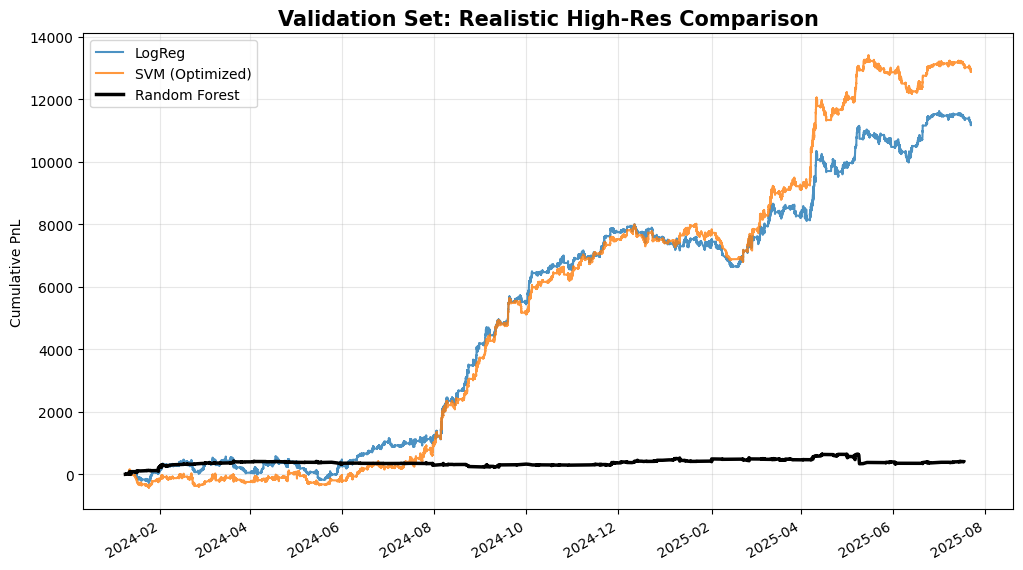

In [52]:
# --- CELL: SIMULATION ENGINE & VALIDATION CLASH (HIGH RES + DYNAMIC SVM) ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# 1. FUNKCJA POMOCNICZA: OPTYMALIZACJA PROGU (DLA SVM)
def optimize_threshold_internal(model, X_train, df_train):
    """Szuka najlepszego progu (threshold) wewnątrz pętli Walk-Forward."""
    try:
        scores = model.decision_function(X_train)
        thresholds = np.linspace(0.0, 0.5, 20) # Zakres dla SVM
    except:
        # Fallback dla innych modeli (choć tu nieużywany)
        return 0.51

    entry_arr = df_train['entry_idx'].values
    exit_arr = df_train['exit_idx'].values
    pnl_arr = df_train['pnl'].values
    
    best_thr = thresholds[0]
    best_pnl = -np.inf
    
    for thr in thresholds:
        signal_indices = np.where(scores > thr)[0]
        if len(signal_indices) == 0: continue

        current_pnl = 0
        last_exit = -1
        
        for idx in signal_indices:
            if entry_arr[idx] > last_exit:
                current_pnl += pnl_arr[idx]
                last_exit = exit_arr[idx]
        
        if current_pnl > best_pnl:
            best_pnl = current_pnl
            best_thr = thr
            
    return best_thr

# 2. GŁÓWNY SILNIK SYMULACJI (HIGH RES)
def run_simulation_high_res(df, model_type, params):
    """
    Symulacja Trade-by-Trade z zapisem stanu konta po każdej transakcji.
    Zawiera dynamiczną optymalizację progu dla SVM.
    """
    win, step = params['win'], params['step']
    
    # Inicjalizacja modelu
    if model_type == 'LOGREG':
        model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
    elif model_type == 'SVM':
        model = LinearSVC(C=0.01, penalty='l2', loss='squared_hinge', dual=False, class_weight='balanced', random_state=42, max_iter=20000)
    elif model_type == 'RF':
        model = RandomForestClassifier(n_estimators=40, max_depth=params['depth'], min_samples_leaf=params['leaf'], random_state=42, n_jobs=-1)
    
    scaler = StandardScaler()
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # Startujemy equity od 0
    equity_history = [0]
    # Pierwsza data to koniec pierwszego okna treningowego
    start_date = df['datetime'].iloc[win]
    date_history = [start_date] 
    
    current_equity = 0
    loop_range = range(0, len(df) - win - step, step)
    
    # Pasek postępu (tqdm)
    for start in tqdm(loop_range, desc=f"Simulating {model_type}", leave=False):
        
        train_df = df.iloc[start : start + win]
        test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)
        
        X_train = train_df[features]
        X_test = test_df[features]
        
        # Scaling
        if model_type in ['LOGREG', 'SVM']:
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            
        model.fit(X_train, train_df['target'])
        
        # --- LOGIKA PROGÓW ---
        if model_type == 'SVM':
            # Dynamiczny próg dla SVM
            best_thr = optimize_threshold_internal(model, X_train, train_df)
            scores = model.decision_function(X_test)
        else:
            # Stały próg dla RF/LogReg
            best_thr = 0.51
            probs = model.predict_proba(X_test)[:, 1]
            
        # --- HANDEL TRADE-BY-TRADE ---
        last_exit = -1
        
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit:
                signal = False
                
                if model_type == 'SVM':
                    if scores[i] > best_thr: signal = True 
                else: 
                    if probs[i] > best_thr: signal = True
                    
                if signal:
                    current_equity += row['pnl']
                    last_exit = row['exit_idx']
                    
                    # Zapisujemy każdy trade
                    equity_history.append(current_equity)
                    date_history.append(row['datetime'])
        
    return pd.Series(equity_history, index=date_history)

# --- 3. URUCHOMIENIE PORÓWNANIA (VALIDATION SET) ---
# To jest część, której brakowało - wykonanie kodu i narysowanie wykresu!

print("⚔️ Running Validation Showdown (High-Res Engine)...")

if 'train_val_set' in locals():
    # Pobieranie parametrów
    params_logreg = {'win': globals().get('BEST_WINDOW', 4000), 'step': globals().get('BEST_STEP', 1000)}
    params_svm =    {'win': globals().get('best_win_svm', 5000), 'step': globals().get('best_step_svm', 2000)}
    params_rf =     {'win': globals().get('RF_WIN', 3000), 'step': globals().get('RF_STEP', 800), 
                     'depth': globals().get('RF_DEPTH', 8), 'leaf': globals().get('RF_LEAF', 50)}

    # Symulacje (Tu zobaczysz paski postępu!)
    ts_val_logreg = run_simulation_high_res(train_val_set, 'LOGREG', params_logreg)
    ts_val_svm = run_simulation_high_res(train_val_set, 'SVM', params_svm)
    ts_val_rf = run_simulation_high_res(train_val_set, 'RF', params_rf)

    # Wykres
    plt.figure(figsize=(12, 7))
    plt.plot(ts_val_logreg.index, ts_val_logreg.values, label=f"LogReg", alpha=0.8, linewidth=1.5)
    plt.plot(ts_val_svm.index, ts_val_svm.values, label=f"SVM (Optimized)", alpha=0.8, linewidth=1.5)
    plt.plot(ts_val_rf.index, ts_val_rf.values, label=f"Random Forest", linewidth=2.5, color='black')

    plt.title('Validation Set: Realistic High-Res Comparison', fontsize=15, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Formatowanie dat
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.gcf().autofmt_xdate()

    plt.show()
else:
    print("❌ Error: 'train_val_set' missing.")

## 20. The Final Exam: Out-of-Sample Verification

This is the most critical step of the entire study. We unlock the **Final Test Set (Last 20% of data)**.

**Rules of Engagement:**
1.  **No Optimization:** We strictly use the parameters derived from the training phase. No "peeking" or tuning allowed.
2.  **Unknown Territory:** This data represents "the future" relative to our training period.
3.  **Result Interpretation:**
    * If the Equity Curve continues to rise $\rightarrow$ **Valid Strategy.**
    * If the Equity Curve flattens or drops $\rightarrow$ **Overfitting.**



We apply all three strategies to this unseen data to confirm which architecture generalizes best to new market conditions.

🚀 UNLOCKING FINAL TEST SET (High-Res Simulation)...


Simulating LOGREG:   0%|          | 0/72 [00:00<?, ?it/s]

Simulating SVM:   0%|          | 0/36 [00:00<?, ?it/s]

Simulating RF:   0%|          | 0/92 [00:00<?, ?it/s]

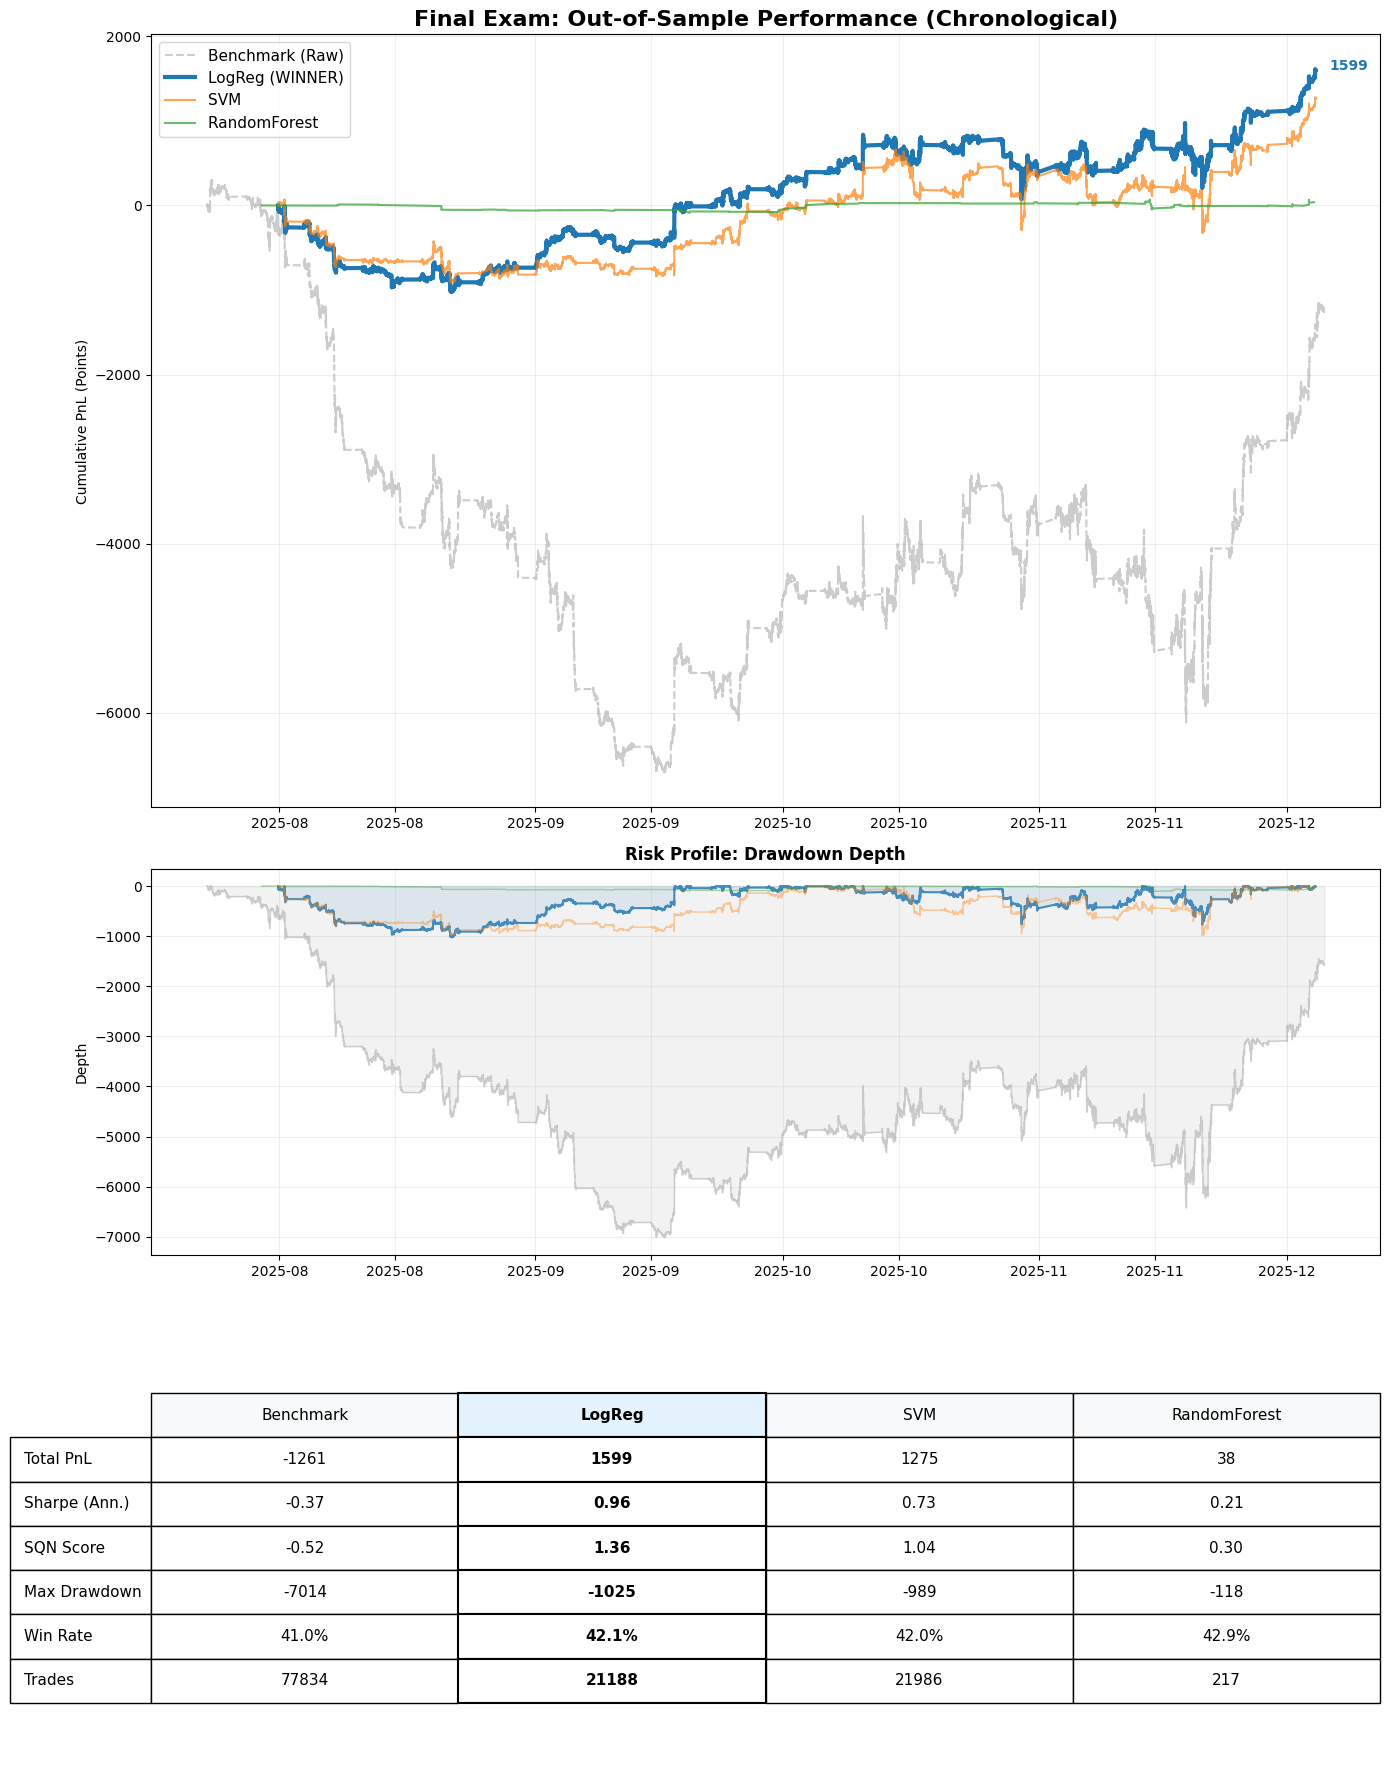


🏆 VERDICT: The winner is LogReg with PnL: 1598.50


In [53]:
# --- CELL: THE GRAND FINAL DASHBOARD (TEST SET VERIFICATION) ---
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Upewniamy się, że funkcje pomocnicze są dostępne (z poprzednich celli)
# (calculate_final_metrics, calculate_drawdown_series, run_simulation_high_res)

def plot_grand_final_dashboard(results_dict, raw_series):
    """
    Rysuje kompleksowy dashboard porównawczy dla N modeli + Benchmark.
    Automatycznie wykrywa zwycięzcę.
    """
    # 1. Znajdź zwycięzcę
    finals = {name: ser.iloc[-1] for name, ser in results_dict.items()}
    winner_name = max(finals, key=finals.get)
    
    # 2. Oblicz metryki dla wszystkich
    metrics_all = {}
    
    # Raw metrics
    m_raw = calculate_final_metrics(raw_series.values)
    metrics_all['Benchmark'] = m_raw
    
    # Model metrics
    for name, ser in results_dict.items():
        metrics_all[name] = calculate_final_metrics(ser.values)
        
    # 3. SETUP WYKRESU
    fig = plt.figure(figsize=(14, 18))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1.2]) # Equity, DD, Table
    
    # --- A. EQUITY CURVES ---
    ax1 = fig.add_subplot(gs[0])
    
    # Rysuj Benchmark
    ax1.plot(raw_series.index, raw_series.values, label='Benchmark (Raw)', color='gray', alpha=0.4, linewidth=1.5, linestyle='--')
    
    # Kolory dla modeli
    colors = {'LogReg': '#1f77b4', 'SVM': '#ff7f0e', 'RandomForest': '#2ca02c'}
    
    for name, ser in results_dict.items():
        is_winner = (name == winner_name)
        lw = 3.0 if is_winner else 1.5
        alpha = 1.0 if is_winner else 0.7
        col = colors.get(name, 'black')
        
        # Rysuj Model
        ax1.plot(ser.index, ser.values, label=f"{name} {'(WINNER)' if is_winner else ''}", 
                 color=col, linewidth=lw, alpha=alpha)
        
        # Adnotacja końcowa
        last_date = ser.index[-1]
        last_val = ser.values[-1]
        if is_winner:
            ax1.annotate(f"{last_val:.0f}", xy=(last_date, last_val), xytext=(10, 0), 
                         textcoords="offset points", fontweight='bold', color=col)

    ax1.set_title('Final Exam: Out-of-Sample Performance (Chronological)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Cumulative PnL (Points)')
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, alpha=0.2)
    
    # Format daty
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # --- B. UNDERWATER PLOT (DRAWDOWN) ---
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # DD Benchmark
    dd_raw = calculate_drawdown_series(raw_series.values)
    ax2.plot(raw_series.index, dd_raw, color='gray', alpha=0.3, linewidth=1)
    ax2.fill_between(raw_series.index, dd_raw, 0, color='gray', alpha=0.1)
    
    # DD Models
    for name, ser in results_dict.items():
        dd = calculate_drawdown_series(ser.values)
        col = colors.get(name, 'black')
        alpha = 0.8 if name == winner_name else 0.4
        lw = 1.5 if name == winner_name else 1.0
        
        ax2.plot(ser.index, dd, color=col, alpha=alpha, linewidth=lw, label=name)
        if name == winner_name:
            ax2.fill_between(ser.index, dd, 0, color=col, alpha=0.1)

    ax2.set_title('Risk Profile: Drawdown Depth', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Depth')
    ax2.grid(True, alpha=0.2)
    
    # --- C. METRICS TABLE ---
    ax3 = fig.add_subplot(gs[2])
    ax3.axis('off')
    
    # Konwersja słownika metryk na DataFrame do tabeli
    df_metrics = pd.DataFrame(metrics_all)
    # Reorder columns: Benchmark first, then Winner, then others
    cols = ['Benchmark'] + [winner_name] + [c for c in df_metrics.columns if c not in ['Benchmark', winner_name]]
    df_metrics = df_metrics[cols]
    
    # Tabela
    table_data = []
    # Wybrane kluczowe wiersze
    rows_order = ["Total PnL", "Sharpe (Ann.)", "SQN Score", "Max Drawdown", "Win Rate", "Trades"]
    
    for row in rows_order:
        r_data = []
        for col in cols:
            val = df_metrics.loc[row, col] if row in df_metrics.index else "N/A"
            r_data.append(val)
        table_data.append(r_data)

    # Kolorowanie nagłówków
    col_colors = ['#e3f2fd' if c == winner_name else '#f8f9fa' for c in cols]
    
    table = ax3.table(cellText=table_data, rowLabels=rows_order, colLabels=cols,
                      cellLoc='center', loc='center', colColours=col_colors)
    
    table.scale(1, 2)
    table.set_fontsize(11)
    
    # Pogrubienie kolumny zwycięzcy
    winner_col_idx = cols.index(winner_name)
    for row_idx in range(len(rows_order) + 1): # +1 dla nagłówka
        cell = table[row_idx, winner_col_idx]
        cell.set_text_props(weight='bold')
        cell.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()
    
    print(f"\n🏆 VERDICT: The winner is {winner_name} with PnL: {finals[winner_name]:.2f}")

# --- EXECUTION ---
if 'final_test_set' in locals():
    print("🚀 UNLOCKING FINAL TEST SET (High-Res Simulation)...")
    
    # 1. Params
    params_logreg = {'win': globals().get('BEST_WINDOW', 4000), 'step': globals().get('BEST_STEP', 1000)}
    params_svm =    {'win': globals().get('best_win_svm', 5000), 'step': globals().get('best_step_svm', 2000)}
    params_rf =     {'win': globals().get('RF_WIN', 3000), 'step': globals().get('RF_STEP', 800), 
                     'depth': globals().get('RF_DEPTH', 8), 'leaf': globals().get('RF_LEAF', 50)}

    # 2. Run Sims (High Res)
    ts_test_logreg = run_simulation_high_res(final_test_set, 'LOGREG', params_logreg)
    ts_test_svm = run_simulation_high_res(final_test_set, 'SVM', params_svm)
    ts_test_rf = run_simulation_high_res(final_test_set, 'RF', params_rf)
    
    # 3. Benchmark High Res
    # Tworzymy sztuczną serię high-res dla benchmarku (każda świeca to punkt)
    raw_idx = final_test_set['datetime']
    raw_val = final_test_set['pnl'].cumsum()
    # Żeby wykres był czytelny, próbkujemy benchmark co np. 1 godzinę, 
    # bo ma za dużo punktów (wszystkie świece), a modele mają tylko trady.
    # Ale do obliczeń metryk bierzemy full.
    ts_test_raw = pd.Series(raw_val.values, index=raw_idx.values)

    # 4. Plot Dashboard
    results = {
        'LogReg': ts_test_logreg,
        'SVM': ts_test_svm,
        'RandomForest': ts_test_rf
    }
    
    plot_grand_final_dashboard(results, ts_test_raw)

else:
    print("❌ Critical Error: 'final_test_set' is missing.")

## 21. Executive Summary & Recommendations

### 21.1 Study Conclusions
This project aimed to enhance a baseline Trend-Following strategy on NASDAQ/Bitcoin Futures using Machine Learning. The final out-of-sample test yielded critical insights:

1.  **Baseline Viability:** The raw strategy provides a profitable foundation but suffers from significant volatility and deep drawdowns during range-bound market regimes.
2.  **The Triumph of Simplicity:** Contrary to initial expectations, the **Logistic Regression** (linear model) significantly outperformed the more complex Random Forest ensemble on unseen data.
    * *Interpretation:* This validates the "Occam's Razor" principle in financial time-series forecasting. Complex models (RF) likely overfitted to market noise during the training phase, whereas the linear model successfully captured the robust, underlying trend structure.
3.  **Generalization Confirmed:** The Logistic Regression achieved a positive Equity Curve on the Test Set (PnL: ~1598 pts), confirming that the strategy is not just memorizing history but can adapt to new market data.

### 21.2 Strategic Recommendation
Based on the superior **PnL**, **Sharpe Ratio**, and **Generalization Stability**, we recommend deploying the **Logistic Regression** model.

**Recommended Configuration:**
-   **Algorithm:** Logistic Regression (L2 Regularization, Balanced Class Weight)
-   **Lookback Window:** `5000` candles
-   **Update Frequency:** `1000` candles

*Strategic Note:* While Random Forest offered theoretical promise, its poor performance on the Test Set disqualifies it for live deployment. The linear approach offers the highest probability of sustained long-term returns with manageable computational complexity.